In [3]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(ggplot2)
library(microshades)
library(openxlsx)
library(GenomicSEM)
library(lavaanPlot)
library(lavaan)
library(semPlot)
library(ggrepel)

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘gdata::nobs’ by ‘lavaan::nobs’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::first’ by ‘data.table::first’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::last’ by ‘data.table::last’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::resample’ by ‘R.utils::resample’ when loading ‘GenomicSEM’”
Warning message:
“replacing p

In [4]:
#load the metadata file
setwd(dir = "/local1/home/pazweifel/src/blood_analysis")
metadata <- read_tsv("blood_names.tsv", col_names = TRUE)

Rows: 63 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Standard abbreviation, Long name
dbl (1): Number of participants contributing to GWAS

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
metadata$source_DOI <- "10.1038/s41467-023-40679-y"

In [6]:
head(metadata)

Standard abbreviation,Long name,Number of participants contributing to GWAS,source_DOI
<chr>,<chr>,<dbl>,<chr>
PLT-SSC,Platelet side scatter,29675,10.1038/s41467-023-40679-y
PLT-SFL,Platelet side fluorescence,29678,10.1038/s41467-023-40679-y
PLT-FSC,Platelet forward scatter,29662,10.1038/s41467-023-40679-y
PLT-SSC-DW,Platelet side scatter distribution width,29658,10.1038/s41467-023-40679-y
PLT-SFL-DW,Platelet side fluorescence distribution width,29552,10.1038/s41467-023-40679-y
PLT-FSC-DW,Platelet forward scatter distribution width,29618,10.1038/s41467-023-40679-y


In [7]:
write_csv(metadata, "/local1/home/pazweifel/plots/blood/sample_data.csv")

In [8]:
sample_names <- metadata$`Standard abbreviation`

In [9]:
ld <- "/local1/hdata/REF/eur_ref_ld_chr"
weights <- "/local1/hdata/REF/eur_w_ld_chr"
basepath <- "/local1/scratch/pazweifel/sumstats_blood/munged_sumstats/" #phenotype.sumstats.gz
sample_prevalences <- rep(NA, length(sample_names))
population_prevalences <- rep(NA, length(sample_names))

In [10]:
samples <- c()

for (trait in sample_names){
    samples <- c(samples, paste0(basepath, trait, ".sumstats.gz"))
    }

In [11]:
names(samples) <- sample_names

In [12]:
metadata <- rename(metadata, ABBRV = `Standard abbreviation`, Trait = `Long name`, N = `Number of participants contributing to GWAS`)

In [13]:
metadata$ABBRV <- metadata$ABBRV %>% gsub(c("-", "#", "%", "(",")"), c("", "hash", "prctg", "_" ,"_"),.) %>% gsub("#","hash",.) %>% gsub("%","prctg",.) %>% gsub("\\(", "_", .) %>% gsub("\\)","_",.)

Warning message in gsub(c("-", "#", "%", "(", ")"), c("", "hash", "prctg", "_", :
“argument 'pattern' has length > 1 and only the first element will be used”
Warning message in gsub(c("-", "#", "%", "(", ")"), c("", "hash", "prctg", "_", :
“argument 'replacement' has length > 1 and only the first element will be used”


In [14]:
sample_names_all <- metadata$ABBRV

In [15]:
samples_fsc_ssc <- samples[grepl("SSC$|FSC$", names(samples))]

In [16]:
dir.create("matrices", showWarnings = FALSE)

covstruct_blood <- here::here("matrices","FSC_SSC.R")

if (!file.exists(covstruct_blood)){
    ldsc_blood <- ldsc(
                    traits = samples_fsc_ssc,
                    sample.prev = sample_prevalences[1:length(samples_fsc_ssc)],
                    population.prev = population_prevalences[1:length(samples_fsc_ssc)],
                    ld = ld,
                    wld = wld,
                    trait.names = gsub("-", "", names(samples_fsc_ssc))
        )
    dput(ldsc_blood, covstruct_blood, control = c("all", "digits17"))
}

In [17]:
ssc_fsc_covstruct <- dget(here::here("matrices","FSC_SSCR"))

### Full matrix

In [18]:
covstruct_full <- here::here("matrices","all.R")

if (!file.exists(covstruct_full)){
    ldsc_blood <- ldsc(
                    traits = samples,
                    sample.prev = sample_prevalences,
                    population.prev = population_prevalences,
                    ld = ld,
                    wld = wld,
                    trait.names = sample_names_all,
                    stand = TRUE)
    saveRDS(object = ldsc_blood, file = covstruct_full)
}

In [19]:
#smooth the S matrix
require(Matrix)

ssc_fsc_covmmatrix_smoothed <- as.matrix((nearPD(ssc_fsc_covstruct$S, corr = FALSE))$mat)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




In [20]:
#run EFA for different amount of factors specified
#preload the approximated number of model structures for memory efficiency
efa_list <- list(0,0,0,0,0)

require(stats)
#run the factanal function fro different amounts of factors
for (i in 1:length(efa_list)){
    EFA <- factanal(covmat = ssc_fsc_covmmatrix_smoothed, factors = i, rotation = "promax")
    efa_list[[i]] <- EFA

}

In [21]:
lavaan_structures_from_efa <- function(efa_list){
    #initialize the lavaan structure list
    lavaan_structure_list <- rep(list(0),length(efa_list))

    #iterate through the efa list to build the lavaan structures for each model
    for (i in 1:length(efa_list)){
        factor_lavaan_list <- rep(list(0),i)
    
        #extract the relevant trait on factor loadings and define the lavaan structure
        
        for (factor_index in 1:i){
            #for each factor loading column of an i-factor model, extract the names of the relevant traits (loading > 0.2)
            #and paste them together usign lavaan syntax
            loadings <- efa_list[[i]]$loadings[,factor_index]
            relevant_loadings_traits <- names(loadings[loadings > 0.2])
            factor_lavaan_list[[factor_index]] <- paste0("F",as.character(factor_index),
                                                 " =~NA*", 
                                                 paste(relevant_loadings_traits, collapse = "+")
                                                 )
            }
    
        #define the correlations between the individual factors if i > 1
             
        if (i > 1){
            factor_numbers <- seq(1,i)
            #get all the pairwise unique combinations of factors
            combination_matrix <- t(combn(factor_numbers, 2))
            print(nrow(combination_matrix))
            factor_correlation_list <- rep(list(0), nrow(combination_matrix))
            for (combination in 1:nrow(combination_matrix)){
                f_left <- as.character(combination_matrix[combination, 1])
                f_right <- as.character(combination_matrix[combination, 2])
        
                factor_correlation_list[[combination]] <- paste0("F",f_left,"~~","F",f_right)
            }
            #collapse the lists and create one lavaan structure object
            collapsed_factor_loadings <- paste(factor_lavaan_list, collapse = "\n")
            collapsed_factor_correlations <- paste(factor_correlation_list, collapse = "\n")
        
            lavaan_structure_list[[i]] <- paste(collapsed_factor_loadings, collapsed_factor_correlations, sep = "\n")
        }
        else{
            lavaan_structure_list[[i]] <- paste(factor_lavaan_list, collapse = "\n")
        }
    }
    lavaan_structure_list
}

In [22]:
lavaan_structure_list <- lavaan_structures_from_efa(efa_list)

[1] 1
[1] 3
[1] 6
[1] 10


In [23]:
lavaan_structure_list[[3]]

[1] "F1 =~NA*RBCSSC+RBCFSC+RETFSC+IRFFSC\nF2 =~NA*NEFSC+EOSSC+EOFSC+BASOFSC\nF3 =~NA*PLTSSC+PLTFSC\nF1~~F2\nF1~~F3\nF2~~F3"

In [24]:
#run the cfa for all efa models using the lavaan strucutres created before and the covariance matrix
cfa_list <- lapply(lavaan_structure_list, function(lavaan_structure){
    usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, CFIcalc = TRUE, std.lv = TRUE, imp_cov = TRUE)
    }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.275 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.315 


Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.387 


Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.893 


Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.618 


Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = lavaan_structure, :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”


In [25]:
modelfit_list <- bind_rows(lapply(cfa_list, function(model) model$modelfit))

In [26]:
modelfit_list

,chisq,df,p_chisq,AIC,CFI,SRMR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df...1,16.50790,2,2.602289e-04,32.50790,0.9988657,0.01452233
df...2,38.03984,19,5.865825e-03,72.03984,0.9986443,0.08116894
df...3,219.80273,32,6.792261e-30,265.80273,0.9904727,0.07411723
df...4,472.90768,45,1.021086e-72,538.90768,0.9807775,0.06548763
df...5,728.07175,65,8.923858e-113,808.07175,0.9749372,0.08576056


In [27]:
write_csv(modelfit_list, "/local1/home/pazweifel/plots/blood/efa_modelfits.csv")

4 factor model loads on all traits and has a better fit than the 5 factor model, so we take this one

In [28]:
semPlotModel_GSEM <- function(gsem.object=cfa_bipolar){ 
        object <- gsem.object$results
        object$free=0
        numb=1:length(which(object$op!="~~"))
        object$free[which(object$op!="~~")]=numb
        varNames <- lavaanNames(object, type = "ov")
        factNames <- lavaanNames(object, type = "lv")
        factNames <- factNames[!factNames %in% varNames]
        n <- length(varNames)
        k <- length(factNames)
        if (is.null(object$label)) 
          object$label <- rep("", nrow(object))
        semModel <- new("semPlotModel")
        object$std <- object[,"STD_Genotype"]
        object$est <- object[,"Unstand_Est"]
        if (is.null(object$group)) 
          object$group <- ""
        semModel@Pars <- data.frame(label = object$label, lhs = ifelse(object$op == "~" | object$op == "~1", object$rhs, object$lhs), edge = "--", 
                                    rhs = ifelse(object$op == "~" | object$op == "~1", object$lhs, object$rhs), est = object$est, std = object$std, std = NA, group = object$group, 
                                    fixed = object$free==0, par = object$free, stringsAsFactors = FALSE)
        semModel@Pars$edge[object$op == "~~"] <- "<->"
        semModel@Pars$edge[object$op == "~*~"] <- "<->"
        semModel@Pars$edge[object$op == "~"] <- "~>"
        semModel@Pars$edge[object$op == "=~"] <- "->"
        semModel@Pars$edge[object$op == "~1"] <- "int"
        semModel@Pars$edge[grepl("\\|", object$op)] <- "|"
        semModel@Thresholds <- semModel@Pars[grepl("\\|", semModel@Pars$edge), 
                                             -(3:4)]
        semModel@Pars <- semModel@Pars[!object$op %in% c(":=", "<", 
                                                         ">", "==", "|", "<", ">"), ]
        semModel@Vars <- data.frame(name = c(varNames, factNames), 
                                    manifest = c(varNames, factNames) %in% varNames, exogenous = NA, 
                                    stringsAsFactors = FALSE)
        semModel@ObsCovs <- list()
        semModel@ImpCovs <- list()
        semModel@Computed <- FALSE
        semModel@Original <- list(object)
        return(semModel)
 }

In [29]:
for (i in 1:length(cfa_list)){
    #define the two sem objects
    current_fit <- semPlotModel_GSEM(gsem.object = cfa_list[[i]])

    #extract the std estimate and the corresponding se to plot them both, for common and independent model
    se <- cfa_list[[i]]$results$STD_Genotype_SE
    est <- cfa_list[[i]]$results$STD_Genotype
    est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")
    print(est.se)

    pdf(paste0("/local1/home/pazweifel/plots/blood/fsc_ssc/",as.character(i),"_factor_model.pdf"), width = 30, height = 20)
    semPaths(current_fit, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 5, sizeLat = 5, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.2,
        esize = 0.5,
        edgeLabels = est.se)
    dev.off()
}  

[1] "0.86\n (0.13)" "0.96\n (0.11)" "0.97\n (0.11)" "0.91\n (0.13)"
[5] "0.26\n (0.09)" "0.07\n (0.03)" "0.05\n (0.02)" "0.17\n (0.04)"
[9] "1\n (NA)"     
 [1] "0.86\n (0.13)" "0.96\n (0.11)" "0.98\n (0.11)" "0.91\n (0.13)"
 [5] "0.17\n (0.1)"  "0.79\n (0.18)" "1.03\n (0.27)" "0.34\n (0.14)"
 [9] "0\n (0.08)"    "0.26\n (0.09)" "0.07\n (0.03)" "0.05\n (0.02)"
[13] "0.17\n (0.04)" "0.97\n (0.12)" "0.37\n (0.33)" "-0.06\n (0.5)"
[17] "0.89\n (0.38)" "1\n (NA)"      "1\n (NA)"     
 [1] "0.91\n (0.14)"  "0.91\n (0.12)"  "0.95\n (0.11)"  "0.94\n (0.12)" 
 [5] "0.17\n (0.1)"   "0.79\n (0.18)"  "1.02\n (0.27)"  "0.35\n (0.14)" 
 [9] "0.92\n (0.22)"  "0.99\n (0.25)"  "-0.01\n (0.08)" "-0.06\n (0.06)"
[13] "-0.04\n (0.08)" "0.16\n (0.4)"   "0.02\n (0.46)"  "0.17\n (0.1)"  
[17] "0.17\n (0.05)"  "0.1\n (0.04)"   "0.12\n (0.06)"  "0.97\n (0.12)" 
[21] "0.38\n (0.32)"  "-0.04\n (0.49)" "0.88\n (0.38)"  "1\n (NA)"      
[25] "1\n (NA)"       "1\n (NA)"      
 [1] "0.91\n (0.14)"  "0.87\n (0.12)" 

Best candidate model 4 so far, reload the model but restrict the residual variance of EOFSC to be positive

In [30]:
lavaan_structure_list[[4]]

[1] "F1 =~NA*RBCSSC+RBCFSC+RETFSC+IRFFSC\nF2 =~NA*NEFSC+EOSSC+EOFSC+BASOFSC\nF3 =~NA*PLTSSC+PLTFSC\nF4 =~NA*EOSSC+EOFSC+BASOFSC+LYSSC+LYFSC\nF1~~F2\nF1~~F3\nF1~~F4\nF2~~F3\nF2~~F4\nF3~~F4"

In [31]:
fsc_ssc_4_factor_model <- 'F1 =~NA*RBCSSC+RBCFSC+RETFSC+IRFFSC
F2 =~NA*NEFSC+EOSSC+EOFSC+BASOFSC
F3 =~NA*PLTSSC+PLTFSC
F4 =~NA*EOSSC+EOFSC+BASOFSC+LYSSC+LYFSC
F1~~F2
F1~~F3
F1~~F4
F2~~F3
F2~~F4
F3~~F4
EOFSC ~~ a*EOFSC
a > 0.0001'

In [32]:
factor4_adjusted.fit <- usermodel(ssc_fsc_covstruct, estimation = "DWLS", model = fsc_ssc_4_factor_model, CFIcalc = TRUE, std.lv = TRUE, imp_cov = TRUE)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.888 


In [33]:
factor4_adjusted.fit

$modelfit
      chisq df      p_chisq      AIC       CFI       SRMR
df 472.4647 45 1.248966e-72 538.4647 0.9807974 0.06552515

$results
       lhs op     rhs  Unstand_Est          Unstand_SE STD_Genotype
6       F1 =~  RBCSSC  0.360579437  0.0550184518135321  0.914769798
5       F1 =~  RBCFSC  0.380656080  0.0534526096984345  0.865162339
7       F1 =~  RETFSC  0.420570042  0.0499297823191319  0.950184708
4       F1 =~  IRFFSC  0.385694669  0.0465906942559755  0.973418249
15      F2 =~   NEFSC  0.094902144  0.0456225039133432  0.216053676
14      F2 =~   EOSSC  0.338399936   0.111096357493566  0.876366987
13      F2 =~   EOFSC  0.323996251    0.10654878827293  1.146317157
12      F2 =~ BASOFSC  0.075782180  0.0419978158462418  0.355513000
20      F3 =~  PLTSSC  0.439362355   0.101812704327069  0.912327754
19      F3 =~  PLTFSC  0.504291906   0.122383244165147  0.995899491
25      F4 =~   EOSSC  0.194442816    0.16252144618674  0.503609595
24      F4 =~   EOFSC  0.163341368   0.147733418472364  0.577910659
23      F4 =~ BASOFSC  0.126531369  0.0535512415222067  0.593656934
27      F4 =~   LYSSC  0.258482789  0.0601614791537666  0.621475911
26      F4 =~   LYFSC  0.219184875  0.0560071075939572  0.747238715
9       F1 ~~      F2  0.073085786    0.10031097940345  0.073099905
10      F1 ~~      F3 -0.065151928  0.0606129658350537 -0.065151796
11      F1 ~~      F4 -0.136895776  0.0968371792598773 -0.136898556
17      F2 ~~      F3 -0.049953741  0.0857101015286987 -0.049948305
18      F2 ~~      F4 -0.467627119   0.377559576504442 -0.467645346
22      F3 ~~      F4  0.019222180  0.0827027322437453  0.019220160
2    EOFSC ~~   EOFSC  0.000100000  0.0403944022535126  0.000100000
34  PLTSSC ~~  PLTSSC  0.038877809  0.0887151653960456  0.167659218
33  PLTFSC ~~  PLTFSC  0.002105132   0.116281147976122  0.008184291
36  RBCSSC ~~  RBCSSC  0.025356577  0.0155566228618677  0.163196656
35  RBCFSC ~~  RBCFSC  0.048684710  0.0113010638016389  0.251494765
37  RETFSC ~~  RETFSC  0.019031487 0.00927213801694749  0.097149542
29  IRFFSC ~~  IRFFSC  0.008236690  0.0122666895477276  0.052456894
32   NEFSC ~~   NEFSC  0.183915720  0.0223695489930533  0.953320897
3    EOSSC ~~   EOSSC  0.058248273  0.0461861799255046  0.391145529
1  BASOFSC ~~ BASOFSC  0.032643211  0.0188580405017422  0.718576982
31   LYSSC ~~   LYSSC  0.106172257  0.0343333588477166  0.613766606
30   LYFSC ~~   LYFSC  0.037996089  0.0242993835288907  0.441634352
8       F1 ~~      F1  1.000000000                      1.000000000
16      F2 ~~      F2  1.000000000                      1.000000000
21      F3 ~~      F3  1.000000000                      1.000000000
28      F4 ~~      F4  1.000000000                      1.000000000
      STD_Genotype_SE      STD_All      p_value
6   0.139578582722727  0.914769597 5.609444e-11
5   0.121488588178522  0.865162063 1.068556e-12
7   0.112806091402523  0.950184460 3.662444e-17
4    0.11758515077853  0.973418258 1.248803e-16
15  0.103860190556447  0.216053667 3.751079e-02
14  0.287709963871037  0.876367130 2.319048e-03
13  0.376999580068545  1.130310704 2.359307e-03
12  0.197028358155628  0.355513115 7.116370e-02
20  0.211416637731784  0.912327230 1.593155e-05
19  0.241690749460346  0.995899447 3.778936e-05
25  0.420890789300213  0.503609677 2.315353e-01
24  0.522742989504608  0.569841077 2.688783e-01
23  0.251240625458852  0.593657127 1.813700e-02
27  0.144646801954021  0.621476249 1.735291e-05
26  0.190936528206468  0.747238696 9.096077e-05
9   0.100306530022616  0.073099905 4.662512e-01
10  0.060613004806848 -0.065151796 2.824265e-01
11 0.0968368002134863 -0.136898556 1.574589e-01
17 0.0857047849831761 -0.049948305 5.600131e-01
18  0.377565792591535 -0.467645346 2.155115e-01
22 0.0827026659425752  0.019220160 8.162080e-01
2   0.505609461633502  0.000100000 9.980248e-01
34  0.382526591352868  0.167659025 6.612182e-01
33  0.453506695630315  0.008184291 9.855560e-01
36  0.100123974569797  0.163196584 1.031113e-01
35 0.0583785374754996  0.2514946

In [34]:
write_csv(factor4_adjusted.fit$modelfit, "/local1/home/pazweifel/plots/blood/modelfit_4.csv")
write_csv(factor4_adjusted.fit$results, "/local1/home/pazweifel/plots/blood/results_4.csv")

Model now looks decent, no residual variance is below 0. One loading is above 1, but with a large error

Refit the covariance matrix with the traits included in this model to check if there is a difference to just doing it for all and subsetting

In [35]:
#extract the names of the remaining traits and subset the sample vector further to only include the relevant traits
names(samples_fsc_ssc) <- gsub("-", "", names(samples_fsc_ssc))
traits_to_keep_factor_4 <- names(samples_fsc_ssc) %in% rownames(factor4_adjusted.fit$resid_cov[[1]])
samples_fsc_ssc_factor_4 <- samples_fsc_ssc[traits_to_keep_factor_4]

In [36]:
names(samples_fsc_ssc_factor_4)

[1] "PLTSSC"  "PLTFSC"  "RBCSSC"  "RBCFSC"  "RETFSC"  "IRFFSC"  "NEFSC"  
 [8] "EOSSC"   "EOFSC"   "BASOFSC" "LYSSC"   "LYFSC"

In [37]:
covstruct_blood <- here::here("matrices","FSC_SSC_factor4.R")

if (!file.exists(covstruct_blood)){
    ldsc_blood <- ldsc(
                    traits = samples_fsc_ssc_factor_4,
                    sample.prev = sample_prevalences[1:length(samples_fsc_ssc_factor_4)],
                    population.prev = population_prevalences[1:length(samples_fsc_ssc_factor_4)],
                    ld = ld,
                    wld = wld,
                    trait.names = names(samples_fsc_ssc_factor_4)
                    
        )
    dput(ldsc_blood, covstruct_blood, control = c("all", "digits17"))
}

In [38]:
#as soon as gwas done delete the one above

covstruct_blood <- here::here("matrices","FSC_SSC_factor4_stand.R")

if (!file.exists(covstruct_blood)){
    ldsc_blood <- ldsc(
                    traits = samples_fsc_ssc_factor_4,
                    sample.prev = sample_prevalences[1:length(samples_fsc_ssc_factor_4)],
                    population.prev = population_prevalences[1:length(samples_fsc_ssc_factor_4)],
                    ld = ld,
                    wld = wld,
                    trait.names = names(samples_fsc_ssc_factor_4),
                    stand = TRUE
                    
        )
    dput(ldsc_blood, covstruct_blood, control = c("all", "digits17"))
}

Check how the covariance matrices compare

In [39]:
covstruct_blood_fsc_ssc_factor4 <- dget(here::here("matrices","FSC_SSC_factor4.R"))

covstruct_blood_fsc_ssc_factor4$S

PLTSSC,PLTFSC,RBCSSC,RBCFSC,RETFSC,IRFFSC,NEFSC,EOSSC,EOFSC,BASOFSC,LYSSC,LYFSC
0.2319170353,0.221566892,-0.0252481077,-0.001354572,-0.0077503772,-0.014635622,0.001905365,-0.0012566713,0.0006819127,-0.018426656,-0.005710249,0.017249848
0.2215668918,0.256415388,-0.0258354064,0.002745385,-0.0066412866,-0.018797888,-0.005709729,-0.0081493131,-0.0104539711,-0.005560890,-0.004327917,0.012437976
-0.0252481077,-0.025835406,0.1553739996,0.144048146,0.1417079500,0.125932300,-0.002021212,-0.0009276574,0.0038161368,-0.023280443,-0.008688276,-0.010054161
-0.0013545724,0.002745385,0.1440481460,0.193583832,0.1859951763,0.148613228,-0.008081742,-0.0046396618,0.0069473152,-0.015290847,0.001934632,-0.007031290
-0.0077503772,-0.006641287,0.1417079500,0.185995176,0.1959106097,0.156572045,0.001433250,-0.0048870185,0.0006414717,-0.022497036,-0.009138521,-0.014032637
-0.0146356225,-0.018797888,0.1259322996,0.148613228,0.1565720452,0.156997092,0.009420056,0.0078807254,0.0088342613,-0.014906989,-0.012829906,-0.017809137
0.0019053650,-0.005709729,-0.0020212120,-0.008081742,0.0014332499,0.009420056,0.192922123,0.0218861292,0.0280117870,-0.007922642,-0.011106944,-0.008322719
-0.0012566713,-0.008149313,-0.0009276574,-0.004639662,-0.0048870185,0.007880725,0.021886129,0.1490315737,0.0861074111,0.024856679,0.008485756,0.007532379
0.0006819127,-0.010453971,0.0038161368,0.006947315,0.0006414717,0.008834261,0.028011787,0.0861074111,0.0799594966,0.020265924,0.001339252,0.007908593
-0.0184266561,-0.005560890,-0.0232804429,-0.015290847,-0.0224970356,-0.014906989,-0.007922642,0.0248566793,0.0202659236,0.045428404,0.026044060,0.004645857


In [40]:
factor4_adjusted_newcovstruct.fit <- usermodel(covstruct_blood_fsc_ssc_factor4, estimation = "DWLS", model = fsc_ssc_4_factor_model, CFIcalc = TRUE, std.lv = TRUE, imp_cov = TRUE)                                   

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.52 


In [41]:
factor4_adjusted_newcovstruct.fit$resid_cov[[1]] - factor4_adjusted.fit$resid_cov[[1]]

,PLTSSC,PLTFSC,RBCSSC,RBCFSC,RETFSC,IRFFSC,NEFSC,EOSSC,EOFSC,BASOFSC,LYSSC,LYFSC
PLTSSC,0,0,0,0,0,0,0,0,0,0,0,0
PLTFSC,0,0,0,0,0,0,0,0,0,0,0,0
RBCSSC,0,0,0,0,0,0,0,0,0,0,0,0
RBCFSC,0,0,0,0,0,0,0,0,0,0,0,0
RETFSC,0,0,0,0,0,0,0,0,0,0,0,0
IRFFSC,0,0,0,0,0,0,0,0,0,0,0,0
NEFSC,0,0,0,0,0,0,0,0,0,0,0,0
EOSSC,0,0,0,0,0,0,0,0,0,0,0,0
EOFSC,0,0,0,0,0,0,0,0,0,0,0,0
BASOFSC,0,0,0,0,0,0,0,0,0,0,0,0


In [42]:
factor4_adjusted_newcovstruct.fit

$modelfit
      chisq df      p_chisq      AIC       CFI       SRMR
df 472.4647 45 1.248966e-72 538.4647 0.9807974 0.06552515

$results
       lhs op     rhs  Unstand_Est          Unstand_SE STD_Genotype
6       F1 =~  RBCSSC  0.360579437  0.0550184518135321  0.914769798
5       F1 =~  RBCFSC  0.380656080  0.0534526096984345  0.865162339
7       F1 =~  RETFSC  0.420570042  0.0499297823191319  0.950184708
4       F1 =~  IRFFSC  0.385694669  0.0465906942559755  0.973418249
15      F2 =~   NEFSC  0.094902144  0.0456225039133432  0.216053676
14      F2 =~   EOSSC  0.338399936   0.111096357493566  0.876366987
13      F2 =~   EOFSC  0.323996251    0.10654878827293  1.146317157
12      F2 =~ BASOFSC  0.075782180  0.0419978158462418  0.355513000
20      F3 =~  PLTSSC  0.439362355   0.101812704327069  0.912327754
19      F3 =~  PLTFSC  0.504291906   0.122383244165147  0.995899491
25      F4 =~   EOSSC  0.194442816    0.16252144618674  0.503609595
24      F4 =~   EOFSC  0.163341368   0.147733418472364  0.577910659
23      F4 =~ BASOFSC  0.126531369  0.0535512415222067  0.593656934
27      F4 =~   LYSSC  0.258482789  0.0601614791537666  0.621475911
26      F4 =~   LYFSC  0.219184875  0.0560071075939572  0.747238715
9       F1 ~~      F2  0.073085786    0.10031097940345  0.073099905
10      F1 ~~      F3 -0.065151928  0.0606129658350537 -0.065151796
11      F1 ~~      F4 -0.136895776  0.0968371792598773 -0.136898556
17      F2 ~~      F3 -0.049953741  0.0857101015286987 -0.049948305
18      F2 ~~      F4 -0.467627119   0.377559576504442 -0.467645346
22      F3 ~~      F4  0.019222180  0.0827027322437453  0.019220160
2    EOFSC ~~   EOFSC  0.000100000  0.0403944022535126  0.000100000
34  PLTSSC ~~  PLTSSC  0.038877809  0.0887151653960456  0.167659218
33  PLTFSC ~~  PLTFSC  0.002105132   0.116281147976122  0.008184291
36  RBCSSC ~~  RBCSSC  0.025356577  0.0155566228618677  0.163196656
35  RBCFSC ~~  RBCFSC  0.048684710  0.0113010638016389  0.251494765
37  RETFSC ~~  RETFSC  0.019031487 0.00927213801694749  0.097149542
29  IRFFSC ~~  IRFFSC  0.008236690  0.0122666895477276  0.052456894
32   NEFSC ~~   NEFSC  0.183915720  0.0223695489930533  0.953320897
3    EOSSC ~~   EOSSC  0.058248273  0.0461861799255046  0.391145529
1  BASOFSC ~~ BASOFSC  0.032643211  0.0188580405017422  0.718576982
31   LYSSC ~~   LYSSC  0.106172257  0.0343333588477166  0.613766606
30   LYFSC ~~   LYFSC  0.037996089  0.0242993835288907  0.441634352
8       F1 ~~      F1  1.000000000                      1.000000000
16      F2 ~~      F2  1.000000000                      1.000000000
21      F3 ~~      F3  1.000000000                      1.000000000
28      F4 ~~      F4  1.000000000                      1.000000000
      STD_Genotype_SE      STD_All      p_value
6   0.139578582722727  0.914769597 5.609444e-11
5   0.121488588178522  0.865162063 1.068556e-12
7   0.112806091402523  0.950184460 3.662444e-17
4    0.11758515077853  0.973418258 1.248803e-16
15  0.103860190556447  0.216053667 3.751079e-02
14  0.287709963871037  0.876367130 2.319048e-03
13  0.376999580068545  1.130310704 2.359307e-03
12  0.197028358155628  0.355513115 7.116370e-02
20  0.211416637731784  0.912327230 1.593155e-05
19  0.241690749460346  0.995899447 3.778936e-05
25  0.420890789300213  0.503609677 2.315353e-01
24  0.522742989504608  0.569841077 2.688783e-01
23  0.251240625458852  0.593657127 1.813700e-02
27  0.144646801954021  0.621476249 1.735291e-05
26  0.190936528206468  0.747238696 9.096077e-05
9   0.100306530022616  0.073099905 4.662512e-01
10  0.060613004806848 -0.065151796 2.824265e-01
11 0.0968368002134863 -0.136898556 1.574589e-01
17 0.0857047849831761 -0.049948305 5.600131e-01
18  0.377565792591535 -0.467645346 2.155115e-01
22 0.0827026659425752  0.019220160 8.162080e-01
2   0.505609461633502  0.000100000 9.980248e-01
34  0.382526591352868  0.167659025 6.612182e-01
33  0.453506695630315  0.008184291 9.855560e-01
36  0.100123974569797  0.163196584 1.031113e-01
35 0.0583785374754996  0.2514946

--> it doesnt matter if you subset, the estimated matrix will be the same, but it might matter for the commonfactor gwas as it need the sumstats to be put in the same order as the sumstats for the ldsc. It might work by including more susmtats than necessary and then filter later, but I think you save time by refitting the covstruct matrix and runnin the sumstats function with less sumstats to process.

## Sumstats preparation for Multivariate GWAS

In [43]:
#extract the names of the traits which are relevant from the initial sample
sample_names_woline <- gsub("-", "", sample_names)
samples_to_keep_commonfactor <- sample_names_woline %in%  rownames(factor4_adjusted.fit$resid_cov[[1]])
commonfactor_samples <- sample_names[samples_to_keep_commonfactor]
names(commonfactor_samples) <- commonfactor_samples

basepath_unmunged_sumstats <- "/local1/scratch/pazweifel/sumstats_blood/sumstats_gsemcompatible/"

sumstats_unmunged_commonfactor <- sapply(commonfactor_samples, function(trait) paste0(basepath_unmunged_sumstats, trait, ".tsv"))

#continuous traits, so OLS = TRUE, se.logit = FALSE 
OLS <- rep(TRUE, length(sumstats_unmunged_commonfactor))
se.logit <- rep(FALSE, length(sumstats_unmunged_commonfactor))                                        
#reference file for maf
ref <- "/local1/scratch/pazweifel/jolien_paper_sumstats/reference.1000G.maf.0.005.txt"

#run the sumstats functio
dir.create("commonfactor", showWarnings = FALSE)

sumstats_path <- here::here("commonfactor","fsc_ssc_factor4_sumstats.R")

if (!file.exists(sumstats_path)){
    combined_sumstats <- sumstats(files = sumstats_unmunged_commonfactor,
                                  ref = ref,
                                  trait.names = names(samples_fsc_ssc_factor_4),
                                  se.logit = se.logit,
                                  OLS = OLS,
                                  parallel = TRUE,
                                  cores = 30)
    saveRDS(combined_sumstats, sumstats_path)
}
                                  
                                  

In [44]:
library(data.table)
hapmap3_snplist <- fread("/local1/scratch/pazweifel/heritability_analysis/w_hm3_snplist.gz", data.table = FALSE)
hapmap3_snps <-hapmap3_snplist$SNP

Warning message:
“package ‘data.table’ was built under R version 4.4.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [45]:
head(hapmap3_snps)

[1] "rs3094315" "rs3131972" "rs3131969" "rs1048488" "rs3115850" "rs2286139"

## Multivariate GWAS 

separately done in the multivariateGWAS_blood.r file to run in the background

In [46]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





In [47]:
blood_gwas <- readRDS("commonfactor/gwas_sumstats_factor4.R")

In [48]:
head(blood_gwas[[1]])

,SNP,CHR,BP,MAF,A1,A2,lhs,op,rhs,free,⋯,est,SE,Z_Estimate,Pval_Estimate,chisq,chisq_df,chisq_pval,AIC,error,warning
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
38,rs3094315,1,752566,0.160040,G,A,F1,~,SNP,17,⋯,-0.003899876,0.007839126,-0.4974886,0.6188446,478.1136,70,4.406524e-62,520.1136,0,0
3858234,rs3131972,1,752721,0.161034,A,G,F1,~,SNP,17,⋯,-0.002116948,0.007896452,-0.2680886,0.7886312,479.3593,70,2.581280e-62,521.3593,0,0
3858239,rs3131969,1,754182,0.128231,A,G,F1,~,SNP,17,⋯,0.001801394,0.008469067,0.2127028,0.8315588,485.1875,70,2.107959e-63,527.1875,0,0
3858245,rs1048488,1,760912,0.160040,C,T,F1,~,SNP,17,⋯,-0.004055625,0.007906965,-0.5129181,0.6080086,479.3654,70,2.574555e-62,521.3654,0,0
3858250,rs3115850,1,761147,0.161034,T,C,F1,~,SNP,17,⋯,-0.002658375,0.007965818,-0.3337228,0.7385888,479.2810,70,2.669564e-62,521.2810,0,0
3858258,rs2286139,1,761732,0.130219,C,T,F1,~,SNP,17,⋯,-0.005047550,0.008149112,-0.6193988,0.5356536,481.0897,70,1.227549e-62,523.0897,0,0


In [49]:
blood_gwas_filtered <- list()

for (i in 1:length(blood_gwas)){
    blood_gwas_filtered_temp <- blood_gwas[[i]] %>% filter(error == 0 & warning == 0 & Pval_Estimate < 0.1)
    blood_gwas_filtered[[i]] <- blood_gwas_filtered_temp
}

In [50]:
nrow(blood_gwas[[1]])
nrow(blood_gwas_filtered[[1]])

[1] 1164662

[1] 129006

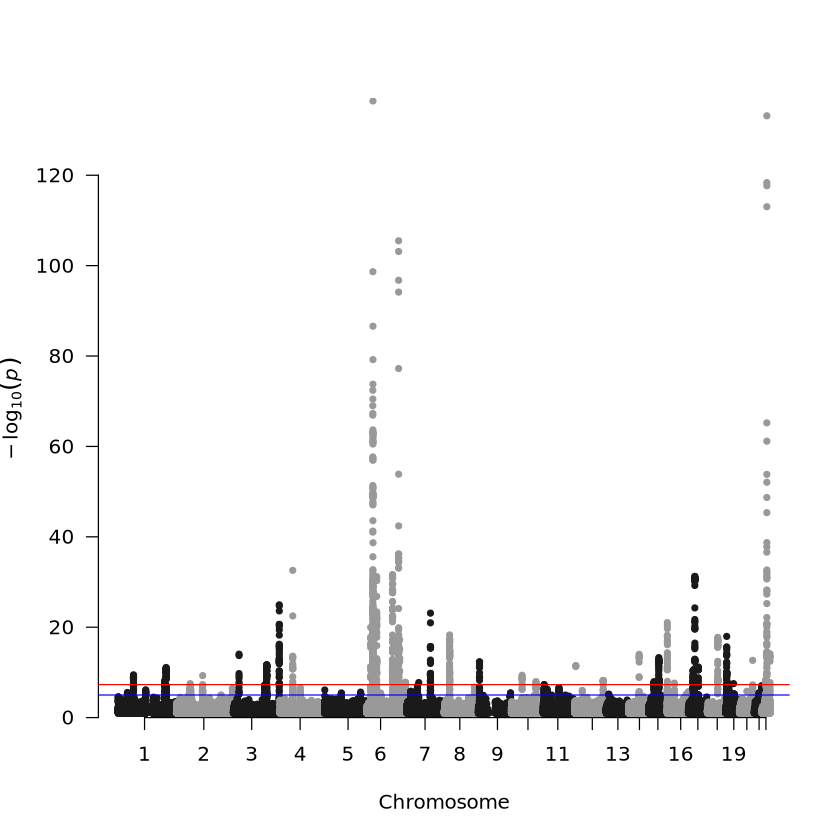

In [51]:
#factor 1
manhattan(blood_gwas_filtered[[1]], chr = "CHR", bp = "BP", p = "Pval_Estimate", snp = "SNP")

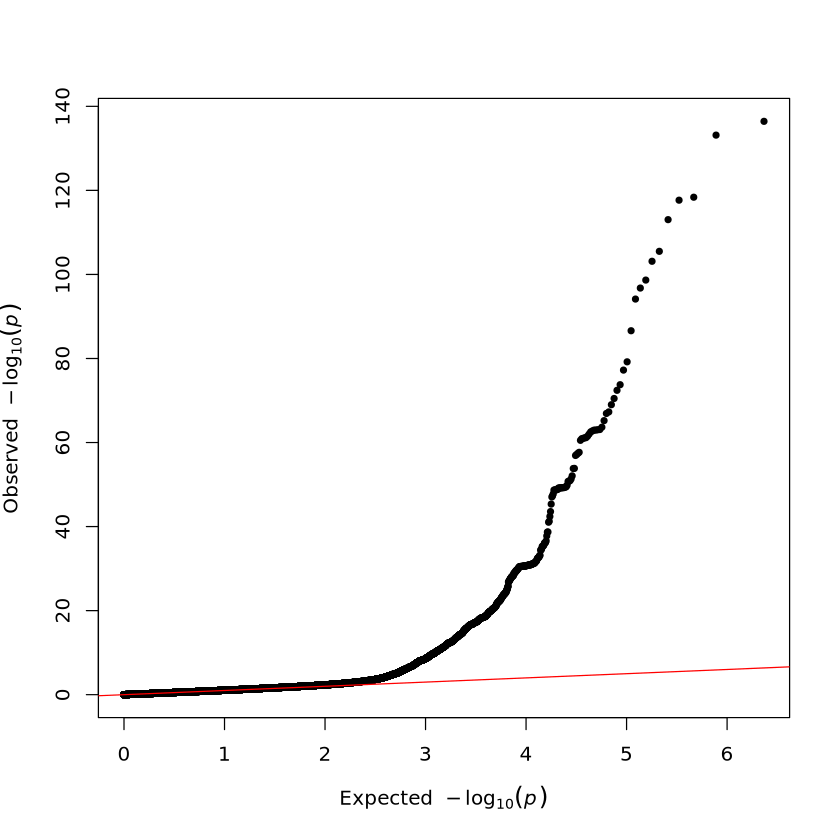

In [52]:
qq(filter(blood_gwas[[1]], warning == 0 & error == 0)$Pval_Estimate)

In [53]:
plot_path <- "/local1/home/pazweifel/plots/blood/fsc_ssc/gwas_factor_"

for (i in 1:length(blood_gwas_filtered)){
  manhattan_path <- paste0(plot_path, i,"_manhattan.pdf")
  qq_path <- paste0(plot_path, i, "_qq.pdf")

  #manhattan
  pdf(file = manhattan_path, width = 10, height = 12)
  manhattan(blood_gwas_filtered[[i]], chr = "CHR", bp = "BP", p = "Pval_Estimate", snp = "SNP")
  dev.off()

  #qq
  pdf(file = qq_path, width = 10, height = 12)
  qq(filter(blood_gwas[[i]], warning == 0 & error == 0)$Pval_Estimate)
  dev.off()
}

## Correlation plot of selected phenotypes

In [54]:
nrow(covstruct_blood_fsc_ssc_factor4$V)

[1] 78

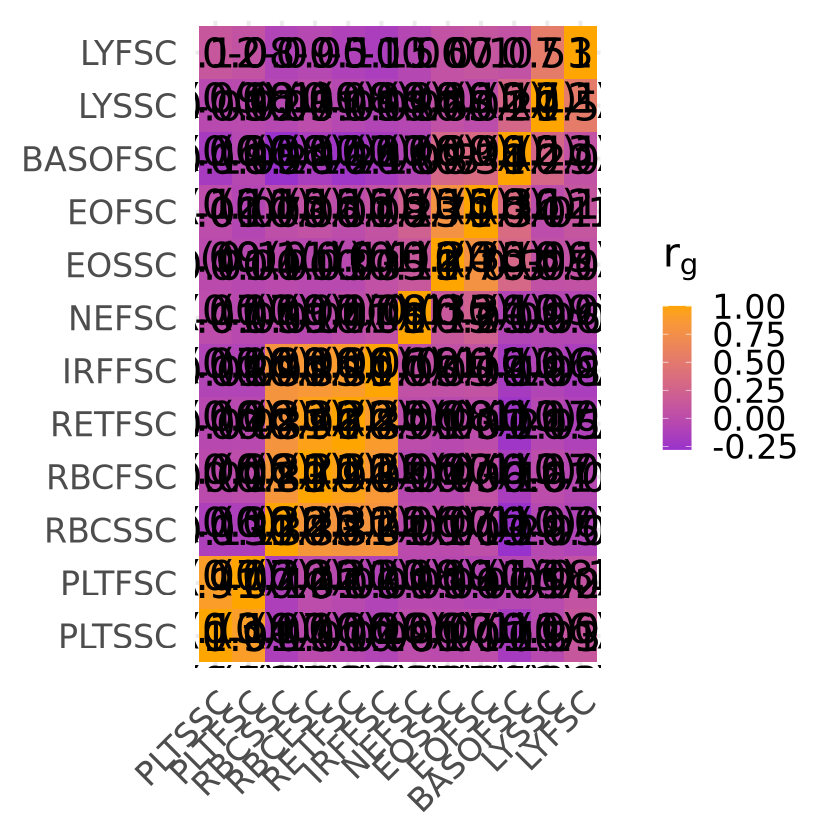

In [55]:
covstruct_blood_fsc_ssc_factor4_stand <- dget(here::here("matrices","FSC_SSC_factor4_stand.R"))

sstand <- covstruct_blood_fsc_ssc_factor4_stand$S_Stand
vstand <- covstruct_blood_fsc_ssc_factor4_stand$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:nrow(covstruct_blood_fsc_ssc_factor4$V)), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
#error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 2)
expanded_df$se <- round(error_vectorized, 2)
#expanded_df
#create the ggplot
correlation_plot <- ggplot(expanded_df, aes(x = x, y = y, fill = values)) +
scale_fill_gradient(low = "darkorchid", high = "orange", limits = c(min(expanded_df$values), max(expanded_df$values))) +
theme_minimal(base_size = 25) +
geom_tile() +
theme(axis.text.x = element_text(angle = 45, hjust = 1), axis.title = element_blank()) +
labs(fill = expression(r[g])) +
geom_text(aes(label = values)) +
geom_text(aes(label = paste0("(",se,")"), vjust = 2))

correlation_plot

In [56]:
ggsave("/local1/home/pazweifel/plots/blood/fsc_ssc/correlation_plot.pdf", correlation_plot, device = pdf, width = 20, height = 17)

In [57]:
write_csv(expanded_df, "/local1/home/pazweifel/plots/blood/correlations.csv")

## Heritabilities

In [58]:
#extract the heritabilities and their se
temp <- covstruct_blood_fsc_ssc_factor4_stand
S <- temp$S
V <- temp$V
herit_base <- sapply(c(1:nrow(S)), function(index) S[index,index])
                  
index_se <- rep(1, nrow(S))

for (i in 2:nrow(S)){
    index_se[i] <- index_se[i-1] + nrow(S) - i + 2
}
                     
se_base <- sapply(index_se, function(index) sqrt(V[index, index]))
           
names <- dimnames(S)[[2]][1:nrow(S)]
                
heritabilities <- tibble(trait = names, heritability = herit_base, se = se_base)

In [59]:
heritabilities

trait,heritability,se
<chr>,<dbl>,<dbl>
PLTSSC,0.23191704,0.03420646
PLTFSC,0.25641539,0.03597199
RBCSSC,0.15537400,0.04089312
RBCFSC,0.19358383,0.04435301
RETFSC,0.19591061,0.04193854
IRFFSC,0.15699709,0.03902525
NEFSC,0.19292212,0.02388783
EOSSC,0.14903157,0.05189652
EOFSC,0.07995950,0.02620346


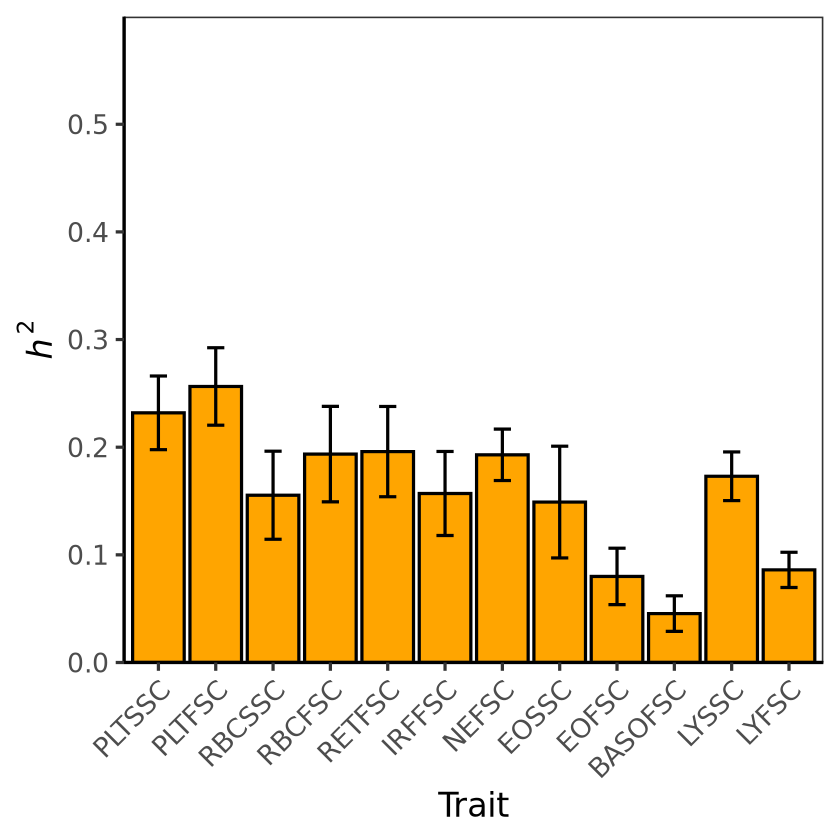

In [60]:

heritabilities$trait <- factor(heritabilities$trait, levels = unique(heritabilities$trait))


heritabilities_blood_paper <- ggplot(heritabilities, aes(x = trait, y = heritability)) + 
geom_col(color = "black", fill = "orange") +
theme_bw() +
geom_errorbar(aes(ymin = heritability - se, ymax = heritability + se), width = 0.3) +
theme_bw(base_size = 20) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), 
axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(x = "Trait", y = expression(italic(h^2))) +
scale_y_continuous(limits = c(0, 0.6), expand = c(0,0))

heritabilities_blood_paper

In [61]:
ggsave("/local1/home/pazweifel/plots//blood/fsc_ssc/heritabilities.pdf", heritabilities_blood_paper, device = pdf, height = 10, width = 10)

In [62]:
write_csv(heritabilities, "/local1/home/pazweifel/plots/blood/heritabilities.csv")

## S-LDSC

In [63]:
sldsc_covstruct <- readRDS("S_LDSC_blood_factors_fsc_ssc.rds")

In [64]:

#specify the model syntax for a common factor model
model<-'F1 =~NA*RBCSSC+RBCFSC+RETFSC+IRFFSC
F2 =~NA*NEFSC+EOSSC+EOFSC+BASOFSC
F3 =~NA*PLTSSC+PLTFSC
F4 =~NA*EOSSC+EOFSC+BASOFSC+LYSSC+LYFSC
F1~~F2
F1~~F3
F1~~F4
F2~~F3
F2~~F4
F3~~F4
EOFSC ~~ a*EOFSC
a > 0.0001'

params<-c("F1~~F1","F2~~F2","F3~~F3","F4~~F4")

#use unit variance identification
std.lv=TRUE

#estimate enrichment using the enrich function
enrich_gwasbysub<-enrich(s_covstruc=sldsc_covstruct,model=model,params=params,std.lv=std.lv, rm_flank = TRUE)

[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 114 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


In [65]:
enrich_blood_tau <- enrich(s_covstruc=sldsc_covstruct,model=model,params=params,std.lv=std.lv, rm_flank = TRUE, tau = TRUE)

[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 114 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


In [66]:
annotations <- list.files(path = "/local1/scratch/pazweifel/single_cell_1k1k_newannot/", pattern = "\\.annot\\.gz$")

In [67]:
tr_annotations <- sub("\\..*", "", annotations)
tr_annotations <- unique(tr_annotations)

In [68]:
length(tr_annotations)

[1] 30

In [69]:
annotations_old <- list.files(path = "/local1/scratch/pazweifel/single_cell_1k1k/", pattern = "\\.annot\\.gz$")

In [70]:
tr_annotations <- sub("\\..*", "", annotations_old)
tr_annotations <- unique(tr_annotations)
length(tr_annotations)

[1] 30

In [71]:
enrich_df <- bind_rows(
    lapply(enrich_gwasbysub[1:4], function(factor) filter(factor, Annotation %in% tr_annotations)), .id = "Factor")

In [72]:
enrich_df_tau <- bind_rows(
    lapply(enrich_blood_tau[1:4], function(factor) filter(factor, Annotation %in% tr_annotations)), .id = "Factor")

In [73]:
tr_annotations

[1] "CD14_low_CD16_positive_monocyte"                    
 [2] "CD14_positive_monocyte"                             
 [3] "CD16_negative_CD56_bright_natural_killer_cell_human"
 [4] "CD4_positive_alpha_beta_cytotoxic_T_cell"           
 [5] "CD4_positive_alpha_beta_T_cell"                     
 [6] "CD8_positive_alpha_beta_T_cell"                     
 [7] "central_memory_CD4_positive_alpha_beta_T_cell"      
 [8] "central_memory_CD8_positive_alpha_beta_T_cell"      
 [9] "Control"                                            
[10] "conventional_dendritic_cell"                        
[11] "dendritic_cell"                                     
[12] "double_negative_thymocyte"                          
[13] "effector_memory_CD4_positive_alpha_beta_T_cell"     
[14] "effector_memory_CD8_positive_alpha_beta_T_cell"     
[15] "erythrocyte"                                        
[16] "gamma_delta_T_cell"                                 
[17] "hematopoietic_precursor_cell"                       
[18] "innate_lymphoid_cell"                               
[19] "memory_B_cell"                                      
[20] "mucosal_invariant_T_cell"                           
[21] "naive_B_cell"                                       
[22] "naive_thymus_derived_CD4_positive_alpha_beta_T_cell"
[23] "naive_thymus_derived_CD8_positive_alpha_beta_T_cell"
[24] "natural_killer_cell"                                
[25] "peripheral_blood_mononuclear_cell"                  
[26] "plasmablast"                                        
[27] "plasmacytoid_dendritic_cell"                        
[28] "platelet"                                           
[29] "regulatory_T_cell"                                  
[30] "transitional_stage_B_cell"

In [74]:
cell_type_groups <- list("T" = c('CD4_positive_alpha_beta_cytotoxic_T_cell', 'CD4_positive_alpha_beta_T_cell', 'CD8_positive_alpha_beta_T_cell','double_negative_thymocyte', 'central_memory_CD4_positive_alpha_beta_T_cell', 'central_memory_CD8_positive_alpha_beta_T_cell', 'effector_memory_CD4_positive_alpha_beta_T_cell', 'effector_memory_CD8_positive_alpha_beta_T_cell', 'gamma_delta_T_cell',  'mucosal_invariant_T_cell', 'naive_thymus_derived_CD4_positive_alpha_beta_T_cell', 'naive_thymus_derived_CD8_positive_alpha_beta_T_cell', 'regulatory_T_cell'),
                         "B" = c('memory_B_cell', 'naive_B_cell', 'transitional_stage_B_cell', 'plasmablast'),
                         "Precursors/Unspecific" = c('hematopoietic_precursor_cell', 'innate_lymphoid_cell', 'peripheral_blood_mononuclear_cell'),
                         "Dendritic" = c('dendritic_cell', 'conventional_dendritic_cell', 'plasmacytoid_dendritic_cell'),
                         "NK" = c('CD16_negative_CD56_bright_natural_killer_cell_human', 'natural_killer_cell'),
                         "Monocytes" = c('CD14_low_CD16_positive_monocyte', 'CD14_positive_monocyte'),
                         "RBC/platelet" = c('erythrocyte', 'platelet'),
                         "Control" = c('Control'))
                      

In [75]:
lookup_groups <- unlist(lapply(names(cell_type_groups), function(g) {
  setNames(rep(g, length(cell_type_groups[[g]])),
           cell_type_groups[[g]])
}))

In [76]:
lookup <- c("1" = "RBC", "2" = "Granulocytes", "3" = "Platelets", "4" = "Lymphocytes/Granulocytes")

enrich_df$Factor <- lookup[enrich_df$Factor]
significance_level <- 0.05/length(unique(enrich_df$Annotation))

enrich_df_tau$Factor <- lookup[enrich_df_tau$Factor]
significance_level <- 0.05/length(unique(enrich_df_tau$Annotation))

factor_order <- c("RBC", "Granulocytes","Platelets","Lymphocytes/Granulocytes")

In [77]:
enrich_df <- enrich_df %>% 
mutate(Bonf = Enrichment_p_value*length(unique(Annotation)), sig = Bonf < 0.05, log10p = -log10(Enrichment_p_value), group = lookup_groups[Annotation], Factor = factor(Factor, levels = factor_order)) %>% 
arrange(Factor, group, Annotation) %>% 
mutate(group = factor(group, levels = unique(group)), Annotation = factor(Annotation, levels = unique(Annotation))) %>%
filter(group != "Control")

In [78]:
enrich_df_tau <- enrich_df_tau %>% 
mutate(Bonf = Enrichment_p_value*length(unique(Annotation)), sig = Bonf < 0.05, log10p = -log10(Enrichment_p_value), group = lookup_groups[Annotation], Factor = factor(Factor, levels = factor_order)) %>% 
arrange(Factor, group, Annotation) %>% 
mutate(group = factor(group, levels = unique(group)), Annotation = factor(Annotation, levels = unique(Annotation))) %>%
filter(group != "Control")

In [79]:
group_colors <- c(
  "T" = "#0072B2",                   # blue
  "B" = "#E69F00",                   # orange
  "Precursors/Unspecific" = "#009E73",  # bluish green
  "Dendritic" = "#CC79A7",           # reddish purple
  "NK" = "#56B4E9",                  # sky blue
  "Monocytes" = "#D55E00",           # vermillion
  "RBC/platelet" = "#F0E442"         # yellow
)

enrich_df$Factor <- recode(enrich_df$Factor, Granulocytes = "F[Gran]", `Lymphocytes/Granulocytes` = "F[GranLy]", Platelets = "F[Plat]", RBC = "F[RBC]")
enrich_df_tau$Factor <- recode(enrich_df_tau$Factor, Granulocytes = "F[Gran]", `Lymphocytes/Granulocytes` = "F[GranLy]", Platelets = "F[Plat]", RBC = "F[RBC]")

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


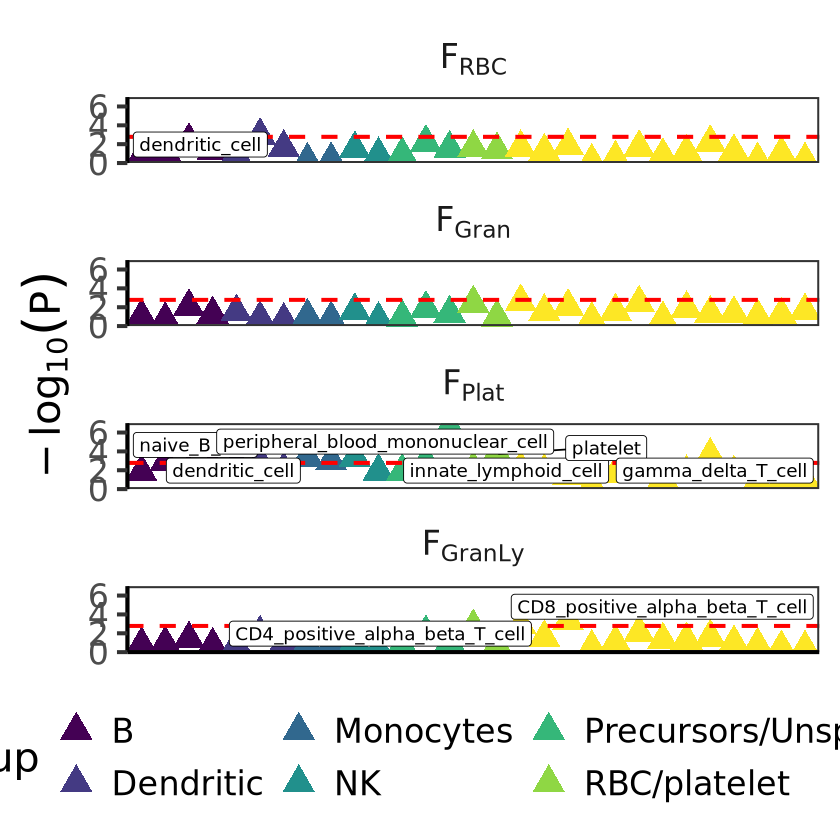

In [80]:
enrich_plot <- ggplot(enrich_df, aes(x = Annotation, y = log10p)) +
geom_point(aes(color = group), size = 6, shape = 17) +
theme_bw(base_size = 25) +
geom_hline(yintercept = -log10(significance_level), color = "red", linetype = "dashed") +
scale_color_viridis_d(option = "D") +
geom_label_repel(data = filter(enrich_df, sig == TRUE), aes(label = Annotation)) +
labs(y = expression(-log[10](P)), color = "Group") +
facet_wrap(vars(Factor), nrow = 4, labeller = label_parsed) + 
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank(), legend.position = "bottom") +
scale_y_continuous(limits = c(0, 7), expand = c(0, 0))



enrich_plot

In [81]:
ggsave(filename = "/local1/home/pazweifel/plots/blood/enrichment_4_factors.pdf", plot = enrich_plot, device = "pdf", width = 20, height = 16)

In [82]:
write_csv(enrich_df, "/local1/home/pazweifel/plots/blood/stratifiedgsem_zerocov_enrichment.csv")

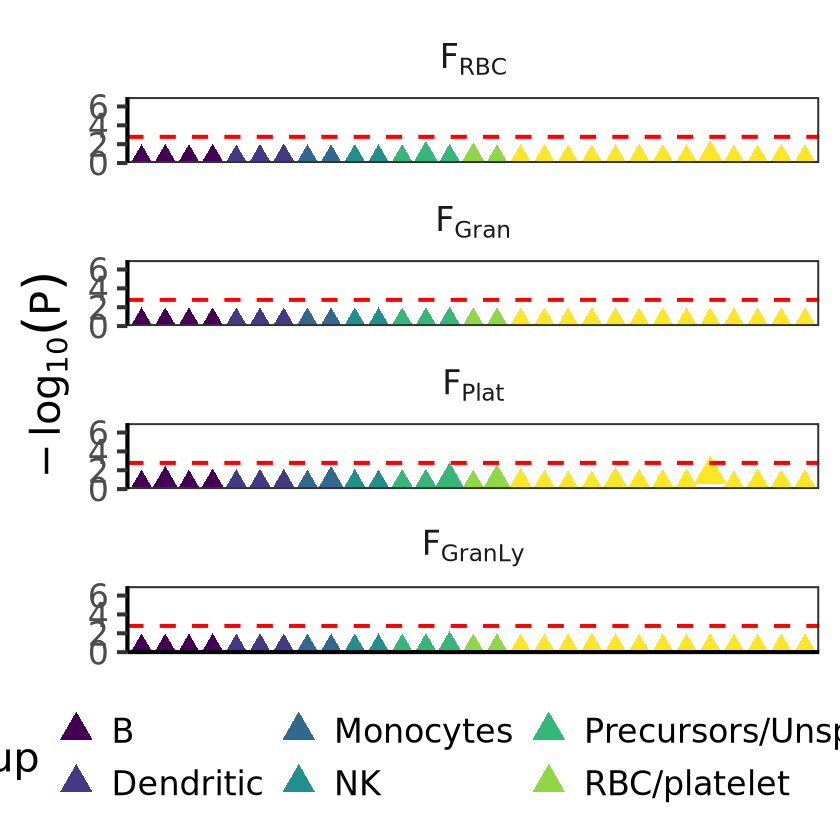

In [83]:
enrich_plot_tau <- ggplot(enrich_df_tau, aes(x = Annotation, y = log10p)) +
geom_point(aes(color = group), size = 6, shape = 17) +
theme_bw(base_size = 25) +
geom_hline(yintercept = -log10(significance_level), color = "red", linetype = "dashed") +
scale_color_viridis_d(option = "D") +
geom_label_repel(data = filter(enrich_df_tau, sig == TRUE), aes(label = Annotation)) +
labs(y = expression(-log[10](P)), color = "Group") +
facet_wrap(vars(Factor), nrow = 4, labeller = label_parsed) + 
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank(), legend.position = "bottom") +
scale_y_continuous(limits = c(0, 7), expand = c(0, 0))



enrich_plot_tau

In [84]:
ggsave(filename = "/local1/home/pazweifel/plots/blood/enrichment_4_factors_taucorrected.pdf", plot = enrich_plot_tau, device = "pdf", width = 20, height = 16)

In [85]:
write_csv(enrich_df_tau, "/local1/home/pazweifel/plots/blood/stratifiedgsem_tau_enrichment.csv")

### Prepare Factors for SLDSC

In [86]:
blood_gwas <- readRDS("commonfactor/gwas_sumstats_factor4.R")

In [87]:
##Calculate Implied Sample Size for Factor
#restrict to MAF >= 10%
blood_gwas_N <- lapply(blood_gwas, function(gwas){
        subby<-subset(gwas, gwas$MAF >= .1)
        
        N_hat_F1<-round(mean(1/((2*subby$MAF*(1-subby$MAF))*subby$SE^2)), 0)
        mutate(tibble(gwas), N = N_hat_F1) %>% rename(P = Pval_Estimate, Z = Z_Estimate, Beta = est) %>% select(SNP, CHR, BP, MAF, A1, A2, Beta, SE, Z, P, N)
    })

In [88]:
dir.create("/local1/scratch/pazweifel/sumstats_blood/factor_sumstats", showWarnings = FALSE)
basepath <- "/local1/scratch/pazweifel/sumstats_blood/factor_sumstats/"
factors <- c("RBC_fsc_ssc_4.tsv", "Gran_fsc_ssc_4.tsv", "Plat_fsc_ssc_4.tsv", "GraLy_fsc_ssc_4.tsv")

blood_filepaths <- paste0(basepath, factors)

for (i in c(1:length(blood_gwas_N))){
    if (!file.exists(blood_filepaths[i])){
        write_tsv(blood_gwas_N[[i]], file = blood_filepaths[i])
        }}

### Plot the LDSC results

In [89]:
cell_type_groups <- list("T" = c('CD4_positive_alpha_beta_cytotoxic_T_cell', 'CD4_positive_alpha_beta_T_cell', 'CD8_positive_alpha_beta_T_cell','double_negative_thymocyte', 'central_memory_CD4_positive_alpha_beta_T_cell', 'central_memory_CD8_positive_alpha_beta_T_cell', 'effector_memory_CD4_positive_alpha_beta_T_cell', 'effector_memory_CD8_positive_alpha_beta_T_cell', 'gamma_delta_T_cell',  'mucosal_invariant_T_cell', 'naive_thymus_derived_CD4_positive_alpha_beta_T_cell', 'naive_thymus_derived_CD8_positive_alpha_beta_T_cell', 'regulatory_T_cell'),
                         "B" = c('memory_B_cell', 'naive_B_cell', 'transitional_stage_B_cell', 'plasmablast'),
                         "Precursors/Unspecific" = c('hematopoietic_precursor_cell', 'innate_lymphoid_cell', 'peripheral_blood_mononuclear_cell'),
                         "Dendritic" = c('dendritic_cell', 'conventional_dendritic_cell', 'plasmacytoid_dendritic_cell'),
                         "NK" = c('CD16_negative_CD56_bright_natural_killer_cell_human', 'natural_killer_cell'),
                         "Monocytes" = c('CD14_low_CD16_positive_monocyte', 'CD14_positive_monocyte'),
                         "RBC/platelet" = c('erythrocyte', 'platelet'),
                         "Control" = c('Control'))

In [90]:
annotation_order_data_labels <- c(
    "B",
    "Dendritic",
    "Monocytes",
    "NK",
    "Precursors/Unspecific",
    "RBC/platelet",
    "T")

In [91]:
lookup_groups <- unlist(lapply(names(cell_type_groups), function(g) {
  setNames(rep(g, length(cell_type_groups[[g]])),
           cell_type_groups[[g]])
}))

In [92]:
#load the data
samples <- c("RBC", "Granulocytes", "Platelets", "Granulocytes/Lymphocytes")
names(samples) <- samples

pathlist <- c("RBC_fsc_ssc_4.h2.cell_type_results.txt", "Gran_fsc_ssc_4.h2.cell_type_results.txt", "Plat_fsc_ssc_4.h2.cell_type_results.txt", "GraLy_fsc_ssc_4.h2.cell_type_results.txt")
names(pathlist) <- samples

enrich_table_common <- bind_rows(lapply(samples, function(sample){
    a <- read_table(pathlist[sample])
    a %>% mutate(Phenotype = sample, Bonfer = Coefficient_P_value*nrow(a), sign = Bonfer < 0.05, BH = p.adjust(Coefficient_P_value, method = "fdr"), Supercluster= factor(lookup_groups[Name], levels = annotation_order_data_labels)) %>% arrange(Supercluster, Name)
    })) %>% mutate(Phenotype = factor(Phenotype, levels = unique(Phenotype)), Name = factor(Name, levels = unique(Name))) 


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)



In [93]:
head(enrich_table_common)

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,Phenotype,Bonfer,sign,BH,Supercluster
<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<lgl>,<dbl>,<fct>
memory_B_cell,-5.028754e-09,5.605947e-09,0.8151510,RBC,23.639379,FALSE,0.9987082,B
naive_B_cell,-1.258488e-09,6.072947e-09,0.5820843,RBC,16.880444,FALSE,0.9987082,B
plasmablast,9.931298e-09,8.041198e-09,0.1084056,RBC,3.143761,FALSE,0.9983393,B
transitional_stage_B_cell,1.404238e-09,6.001899e-09,0.4075059,RBC,11.817670,FALSE,0.9987082,B
conventional_dendritic_cell,-8.941920e-09,7.649568e-09,0.8787870,RBC,25.484823,FALSE,0.9987082,Dendritic
dendritic_cell,9.562057e-09,8.138343e-09,0.1200096,RBC,3.480277,FALSE,0.9983393,Dendritic


In [94]:
p_cut <- max(enrich_table_common$Coefficient_P_value[enrich_table_common$BH <= 0.05], na.rm = TRUE)

enrich_table_common$Phenotype <- recode(enrich_table_common$Phenotype, RBC = "F[RBC]", Granulocytes = "F[Gran]", Platelets = "F[Plat]", `Granulocytes/Lymphocytes` = "F[GranLy]")

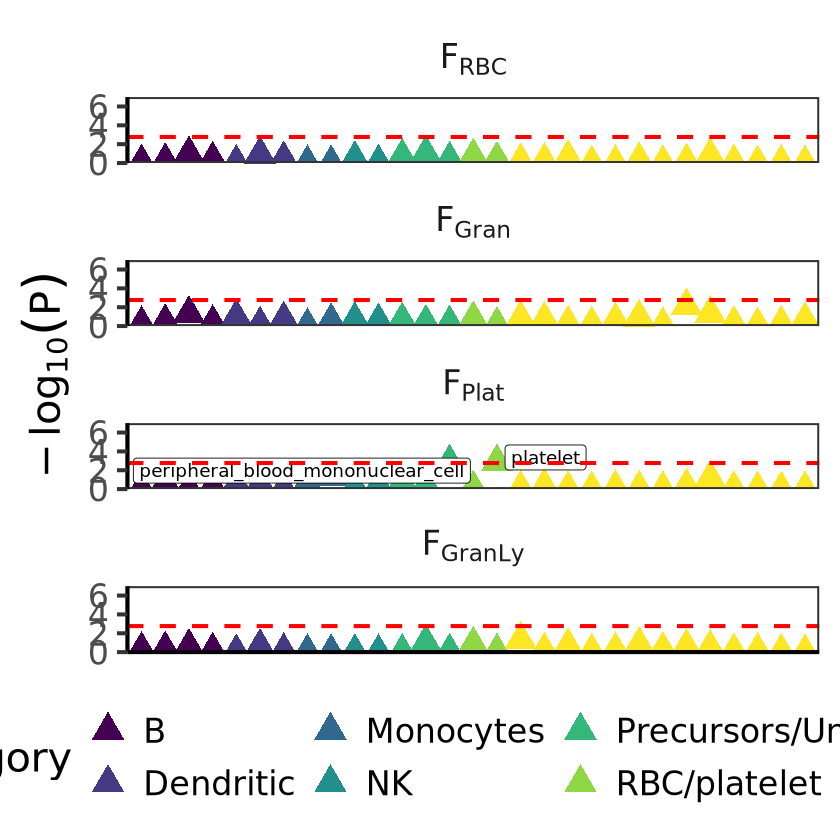

In [95]:
sldsc_plot <- ggplot(enrich_table_common, aes(x = Name, y = -log10(Coefficient_P_value))) +
geom_point(aes(color = Supercluster), size = 6, shape = 17) +
scale_color_viridis_d(option = "D") +
geom_label_repel(data = filter(enrich_table_common, sign == TRUE), aes(label = Name)) +
geom_hline(yintercept = -log10(0.05/length(unique(enrich_table_common$Name))), color = "red", linetype = "dashed") +
labs(y = expression(-log[10](P)), color = "Category") + 
facet_wrap(vars(Phenotype), nrow = 5, labeller = label_parsed) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank(), legend.position = "bottom") +
scale_y_continuous(limits = c(0, 7), expand = c(0, 0))

sldsc_plot

In [96]:
ggsave("/local1/home/pazweifel/plots/blood/sldsc_4_factors.pdf", plot = sldsc_plot, device = "pdf", width = 20, height = 16)

In [97]:
write_csv(enrich_table_common, "/local1/home/pazweifel/plots/blood/sldsc_enrichment.csv")

### Load and plot the SLDSC results for the individual GWAS

In [98]:
sldsc_results_paths <- list.files("sldsc_original_sumstats", pattern = "cell_type_results\\.txt$", full.names = TRUE)

In [99]:
sldsc_results_names <- list.files("sldsc_original_sumstats", pattern = "cell_type_results\\.txt$", full.names = FALSE)
sldsc_results_names <- str_remove(sldsc_results_names, pattern = ".h2.cell_type_results.txt")

In [100]:
names(sldsc_results_names) <- sldsc_results_names
names(sldsc_results_paths) <- sldsc_results_names

In [101]:
enrich_table_original_sumstats <- bind_rows(lapply(sldsc_results_names, function(sample){
    a <- read_table(sldsc_results_paths[sample])
    a %>% mutate(Phenotype = sample, Bonfer = Coefficient_P_value*nrow(a), sign = Bonfer < 0.05, BH = p.adjust(Coefficient_P_value, method = "fdr"), Supercluster= factor(lookup_groups[Name], levels = annotation_order_data_labels)) %>% arrange(Supercluster, Name)
    })) %>% mutate(Phenotype = factor(Phenotype, levels = unique(Phenotype)), Name = factor(Name, levels = unique(Name))) 


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ────────────────────────────────────────────────────────
cols(
  Name = col_cha

In [102]:
p_cut <- max(enrich_table_original_sumstats$Coefficient_P_value[enrich_table_original_sumstats$BH <= 0.05], na.rm = TRUE)

#enrich_table_original_sumstats$Phenotype <- recode(enrich_table_original_sumstats$Phenotype, RBC = "F[RBC]", Granulocytes = "F[Gran]", Platelets = "F[Plat]", `Granulocytes/Lymphocytes` = "F[GranLy]")

In [103]:
head(enrich_table_original_sumstats)

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,Phenotype,Bonfer,sign,BH,Supercluster
<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<lgl>,<dbl>,<fct>
memory_B_cell,4.233076e-10,8.072273e-09,0.4790892,BASO-FSC-DW,13.89359,FALSE,0.9305763,B
naive_B_cell,-1.383278e-10,7.767975e-09,0.5071038,BASO-FSC-DW,14.70601,FALSE,0.9305763,B
plasmablast,1.916462e-09,1.145812e-08,0.4335835,BASO-FSC-DW,12.57392,FALSE,0.9305763,B
transitional_stage_B_cell,-1.015131e-08,7.275422e-09,0.9185356,BASO-FSC-DW,26.63753,FALSE,0.9305763,B
conventional_dendritic_cell,-8.507613e-09,1.070763e-08,0.7865586,BASO-FSC-DW,22.81020,FALSE,0.9305763,Dendritic
dendritic_cell,3.043919e-09,1.124352e-08,0.3933007,BASO-FSC-DW,11.40572,FALSE,0.9305763,Dendritic


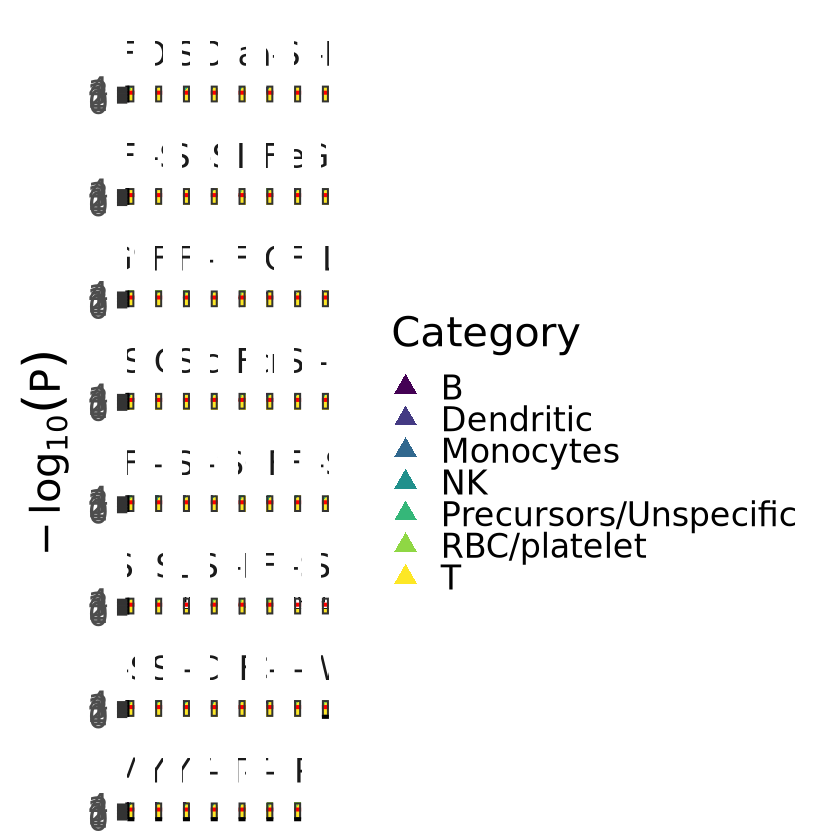

In [104]:
sldsc_plot_originals <- ggplot(enrich_table_original_sumstats, aes(x = Name, y = -log10(Coefficient_P_value))) +
geom_point(aes(color = Supercluster), size = 4, shape = 17) +
scale_color_viridis_d(option = "D") +
geom_label_repel(data = filter(enrich_table_original_sumstats, sign == TRUE), aes(label = Name)) +
geom_hline(yintercept = -log10(0.05/length(unique(enrich_table_original_sumstats$Name))), color = "red", linetype = "dashed") +
labs(y = expression(-log[10](P)), color = "Category") + 
facet_wrap(vars(Phenotype), nrow = 8, ncol = 8) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank()) 

sldsc_plot_originals

In [105]:
ggsave("/local1/home/pazweifel/plots/blood/sldsc_original_datasets.pdf", plot = sldsc_plot_originals, device = "pdf", width = 40, height = 40)

In [106]:
write_csv(enrich_table_original_sumstats, "/local1/home/pazweifel/plots/blood/sldsc_enrichment_original_sumstats.csv")

In [107]:
reticulocyte_measures <- c("LFR","MFR","RPI")

In [108]:
sign_table <- filter(enrich_table_original_sumstats, sign == TRUE) %>% mutate(cell_type = factor(ifelse(Phenotype %in% reticulocyte_measures, "Reticulocyte", "Platelet"), levels = c("Platelet", "Reticulocyte"))) %>% arrange(cell_type, Bonfer) %>% mutate(Phenotype = factor(Phenotype, levels = unique(Phenotype)))

In [109]:
sign_table

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,Phenotype,Bonfer,sign,BH,Supercluster,cell_type
<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<lgl>,<dbl>,<fct>,<fct>
peripheral_blood_mononuclear_cell,6.443744e-08,1.568023e-08,1.982842e-05,P-LCR,0.0005750241,TRUE,0.0005750241,Precursors/Unspecific,Platelet
platelet,6.032481e-08,1.530679e-08,4.056322e-05,P-LCR,0.0011763335,TRUE,0.0005881667,RBC/platelet,Platelet
peripheral_blood_mononuclear_cell,6.215284e-08,1.674605e-08,1.030201e-04,PLT-SSC-DW,0.0029875830,TRUE,0.0029875830,Precursors/Unspecific,Platelet
platelet,6.201228e-08,1.675374e-08,1.072071e-04,IPF%,0.0031090067,TRUE,0.0031090067,RBC/platelet,Platelet
platelet,6.056415e-08,1.742046e-08,2.538982e-04,H-IPF,0.0073630475,TRUE,0.0073630475,RBC/platelet,Platelet
peripheral_blood_mononuclear_cell,6.059375e-08,1.762117e-08,2.922675e-04,PLT-SFL,0.0084757582,TRUE,0.0070746853,Precursors/Unspecific,Platelet
CD14_low_CD16_positive_monocyte,4.274784e-08,1.286739e-08,4.465794e-04,PLT-SFL-DW,0.0129508015,TRUE,0.0129508015,Monocytes,Platelet
platelet,5.683390e-08,1.723594e-08,4.879093e-04,PLT-SFL,0.0141493705,TRUE,0.0070746853,RBC/platelet,Platelet
platelet,5.391405e-08,1.636366e-08,4.925585e-04,PLT-FSC,0.0142841969,TRUE,0.0091873745,RBC/platelet,Platelet


In [110]:
group_colors <- c(
    "Platelet" = "brown",
    "Reticulocyte" = "yellow")

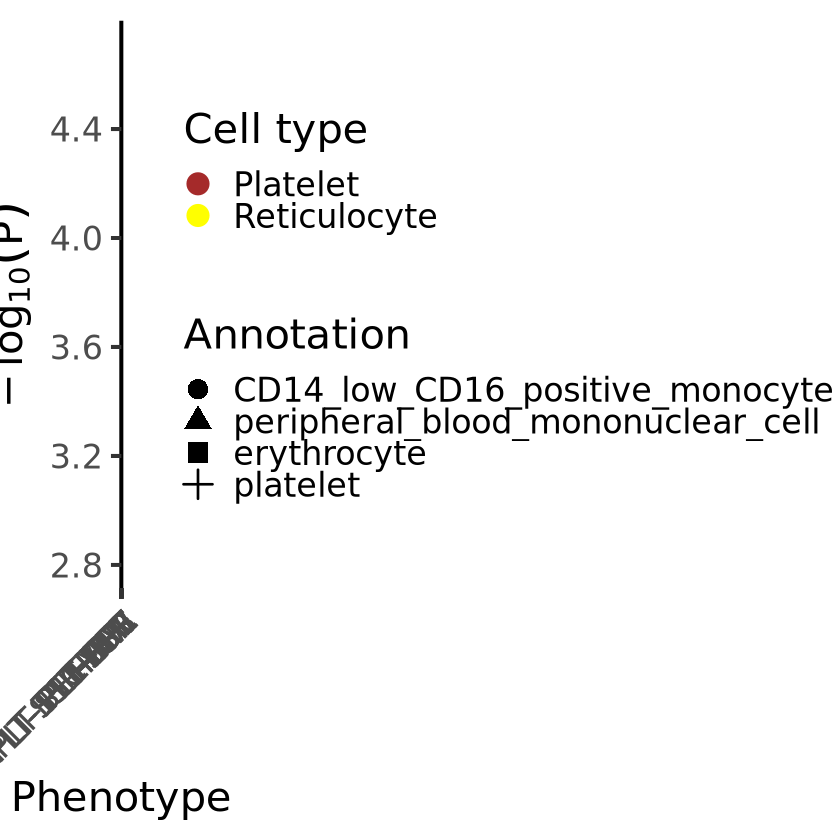

In [111]:
sign_plot <- ggplot(sign_table, aes(x = Phenotype, y = -log10(Coefficient_P_value))) +
geom_point(aes(color = cell_type, shape = Name), size = 5) +
#geom_label_repel(aes(label = Name), ) +
theme_bw(base_size = 25) +
labs(color = "Cell type", shape = "Annotation", y = expression(-log[10](P)), x = "Phenotype") +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_text(angle = 45, hjust = 1)) +
scale_color_manual(values = group_colors) 

sign_plot

In [112]:
ggsave("/local1/home/pazweifel/plots/blood/sign_enrichments_original_sumstats.pdf", device = "pdf", plot = sign_plot, width = 18, height = 10)

plat, plat, reiculo, reticulo, plat, plat, plat, plat, plat, plat, reticulo --> out of the 12 out of 63 phenotypes which showed significant enrichment for at least one annotation, 75% were different measures of Platelets and 25% different measures of Reticulocytes. In a previous analysis, the Platelet side scattering and forward scattering phenotype showed the highest estimated heritability among all cell types measured for SSC and FSC. 

In [113]:
knitr::kable(metadata)



|ABBRV          |Trait                                               |     N|source_DOI                 |
|:--------------|:---------------------------------------------------|-----:|:--------------------------|
|PLTSSC         |Platelet side scatter                               | 29675|10.1038/s41467-023-40679-y |
|PLTSFL         |Platelet side fluorescence                          | 29678|10.1038/s41467-023-40679-y |
|PLTFSC         |Platelet forward scatter                            | 29662|10.1038/s41467-023-40679-y |
|PLTSSCDW       |Platelet side scatter distribution width            | 29658|10.1038/s41467-023-40679-y |
|PLTSFLDW       |Platelet side fluorescence distribution width       | 29552|10.1038/s41467-023-40679-y |
|PLTFSCDW       |Platelet forward scatter distribution width         | 29618|10.1038/s41467-023-40679-y |
|HIPF           |High fluorescence immature platelet fraction        | 36829|10.1038/s41467-023-40679-y |
|IPFhash        |Immature platelet count    

### Load the full covmatrix, group, order and plot covariances

In [114]:
full_covstruct <- readRDS("matrices/all.R")

In [115]:
sstand <- full_covstruct$S_Stand
vstand <- full_covstruct$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:dim(vstand)[1]), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 2)
expanded_df$se <- round(error_vectorized, 2)
expanded_df

PLTSSC,PLTSFL,PLTFSC,PLTSSCDW,PLTSFLDW,PLTFSCDW,HIPF,IPFhash,IPFprctg,PLCR,⋯,MOFSCDW,LYSSC,LYSFL,LYFSC,LYSSCDW,LYSFLDW,LYFSCDW,RELYMPhash,RELYMP_L_prctg,RELYMPprctg
0.12597259,0.10760502,0.11479981,0.08462906,0.08423025,0.09133588,0.09039703,0.08729661,0.09144869,0.09473270,⋯,0.1338766,0.06350558,0.06653999,0.08259244,0.07568486,0.08135115,0.1132871,0.07905629,0.07077776,0.07280287
0.10760502,0.12153235,0.11494073,0.08175787,0.08394905,0.08629087,0.09641648,0.09409317,0.09832372,0.10678227,⋯,0.1299046,0.06157908,0.06446904,0.08055378,0.07176057,0.07829996,0.1111339,0.07728761,0.06897450,0.06992434
0.11479981,0.11494073,0.12529258,0.08230049,0.08301832,0.09368260,0.09312548,0.09071558,0.09583304,0.10049595,⋯,0.1306915,0.06225883,0.06447436,0.08363879,0.07141067,0.08153848,0.1145486,0.08079793,0.07030704,0.07214762
0.08462906,0.08175787,0.08230049,0.13722807,0.10834159,0.09174763,0.08607414,0.08427845,0.08502622,0.08058134,⋯,0.1452726,0.06872162,0.06901435,0.08950057,0.08033384,0.08733733,0.1253728,0.07857340,0.07257919,0.07318493
0.08423025,0.08394905,0.08301832,0.10834159,0.12160814,0.08952034,0.09010815,0.08470799,0.08871839,0.08194769,⋯,0.1334447,0.06189212,0.06555430,0.08287021,0.07474398,0.07956620,0.1171173,0.07661581,0.07039966,0.06946156
0.09133588,0.08629087,0.09368260,0.09174763,0.08952034,0.12397857,0.07274545,0.07032287,0.07517329,0.07703880,⋯,0.1280315,0.05905046,0.06381541,0.08414499,0.06819906,0.07895816,0.1143320,0.07884353,0.06990069,0.07060581
0.09039703,0.09641648,0.09312548,0.08607414,0.09010815,0.07274545,0.11607905,0.10726839,0.11072469,0.09533965,⋯,0.1228103,0.05862352,0.05885641,0.07604978,0.06817417,0.07275294,0.1053836,0.06648311,0.06317482,0.06161567
0.08729661,0.09409317,0.09071558,0.08427845,0.08470799,0.07032287,0.10726839,0.11193154,0.10725388,0.09074331,⋯,0.1227136,0.05813246,0.05991038,0.07445102,0.06735633,0.07105485,0.1034013,0.06764188,0.06360672,0.06282575
0.09144869,0.09832372,0.09583304,0.08502622,0.08871839,0.07517329,0.11072469,0.10725388,0.11510055,0.09718801,⋯,0.1214961,0.05869010,0.05989813,0.07728316,0.06838212,0.07478105,0.1080032,0.06906573,0.06379796,0.06290571
0.09473270,0.10678227,0.10049595,0.08058134,0.08194769,0.07703880,0.09533965,0.09074331,0.09718801,0.11092051,⋯,0.1204806,0.05671655,0.06061292,0.07811415,0.06875879,0.07504473,0.1086900,0.06964590,0.06301297,0.06175312


x,y,values,se
<fct>,<fct>,<dbl>,<dbl>
PLTSSC,PLTSSC,1.00,0.13
PLTSFL,PLTSSC,0.87,0.11
PLTFSC,PLTSSC,0.91,0.11
PLTSSCDW,PLTSSC,-0.12,0.08
PLTSFLDW,PLTSSC,0.04,0.08
PLTFSCDW,PLTSSC,-0.48,0.09
HIPF,PLTSSC,0.72,0.09
IPFhash,PLTSSC,0.74,0.09
IPFprctg,PLTSSC,0.76,0.09


In [144]:
write_csv(expanded_df, "/local1/home/pazweifel/plots/blood/all_correlations.csv")

In [116]:
metadata_expanded <- metadata %>%
  mutate(
    category = case_when(
      # --- MEP: megakaryocyte–erythroid progenitors (platelets / erythrocytes / reticulocytes)
      str_detect(ABBRV, "^(PLT|HIPF|IPF|RBC|RET|HFR|MFR|LFR|IRF|RDW|MacroR|MicroR|HyperHe|DeltaHe|DeltaHGB|RPI)") ~ "MEP",

      # --- GMP: granulocyte–monocyte progenitors (granulocytes + monocytes + dendritic)
      str_detect(ABBRV, "^(NE|IG|EO|BASO|MO)") |
        str_detect(Trait, regex("granulocyte|eosinophil|basophil|neutrophil|monocyte|dendritic", ignore_case = TRUE)) ~ "GMP",

      # --- CLP: common lymphoid progenitors (B/T/NK/lymphocyte)
      str_detect(ABBRV, "^(LY|RELYMP)") |
        str_detect(Trait, regex("lymphocyte|B cell|T cell|natural killer|NK|dendritic", ignore_case = TRUE)) ~ "CLP",

      TRUE ~ "unspecific"
    )
  )

metadata_expanded[metadata_expanded["Trait"] == "Platelet large cell ratio", ]$category <- "MEP"

In [117]:
expanded_df_annotated <- expanded_df %>% left_join(metadata_expanded, by = join_by("x" == "ABBRV"))
head(expanded_df_annotated)

,x,y,values,se,Trait,N,source_DOI,category
,<chr>,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,PLTSSC,PLTSSC,1.00,0.13,Platelet side scatter,29675,10.1038/s41467-023-40679-y,MEP
2,PLTSFL,PLTSSC,0.87,0.11,Platelet side fluorescence,29678,10.1038/s41467-023-40679-y,MEP
3,PLTFSC,PLTSSC,0.91,0.11,Platelet forward scatter,29662,10.1038/s41467-023-40679-y,MEP
4,PLTSSCDW,PLTSSC,-0.12,0.08,Platelet side scatter distribution width,29658,10.1038/s41467-023-40679-y,MEP
5,PLTSFLDW,PLTSSC,0.04,0.08,Platelet side fluorescence distribution width,29552,10.1038/s41467-023-40679-y,MEP
6,PLTFSCDW,PLTSSC,-0.48,0.09,Platelet forward scatter distribution width,29618,10.1038/s41467-023-40679-y,MEP


In [118]:
# 1) set your desired category order (optional but recommended)
expanded_df_annotated$category <- factor(expanded_df_annotated$category, levels = c("MEP", "GMP", "CLP"))

# 2) build a master order for phenotypes (based on category grouping)
ord <- expanded_df_annotated %>%
  distinct(x, category) %>%
  arrange(category, x) %>%
  pull(x)

# 3) apply the same order to BOTH axes
expanded_df_annotated <- expanded_df_annotated %>%
  mutate(
    x = factor(x, levels = ord),
    y = factor(y, levels = ord)   # <-- key line for the diagonal
  )

In [119]:
head(expanded_df_annotated)

,x,y,values,se,Trait,N,source_DOI,category
,<fct>,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<fct>
1,PLTSSC,PLTSSC,1.00,0.13,Platelet side scatter,29675,10.1038/s41467-023-40679-y,MEP
2,PLTSFL,PLTSSC,0.87,0.11,Platelet side fluorescence,29678,10.1038/s41467-023-40679-y,MEP
3,PLTFSC,PLTSSC,0.91,0.11,Platelet forward scatter,29662,10.1038/s41467-023-40679-y,MEP
4,PLTSSCDW,PLTSSC,-0.12,0.08,Platelet side scatter distribution width,29658,10.1038/s41467-023-40679-y,MEP
5,PLTSFLDW,PLTSSC,0.04,0.08,Platelet side fluorescence distribution width,29552,10.1038/s41467-023-40679-y,MEP
6,PLTFSCDW,PLTSSC,-0.48,0.09,Platelet forward scatter distribution width,29618,10.1038/s41467-023-40679-y,MEP


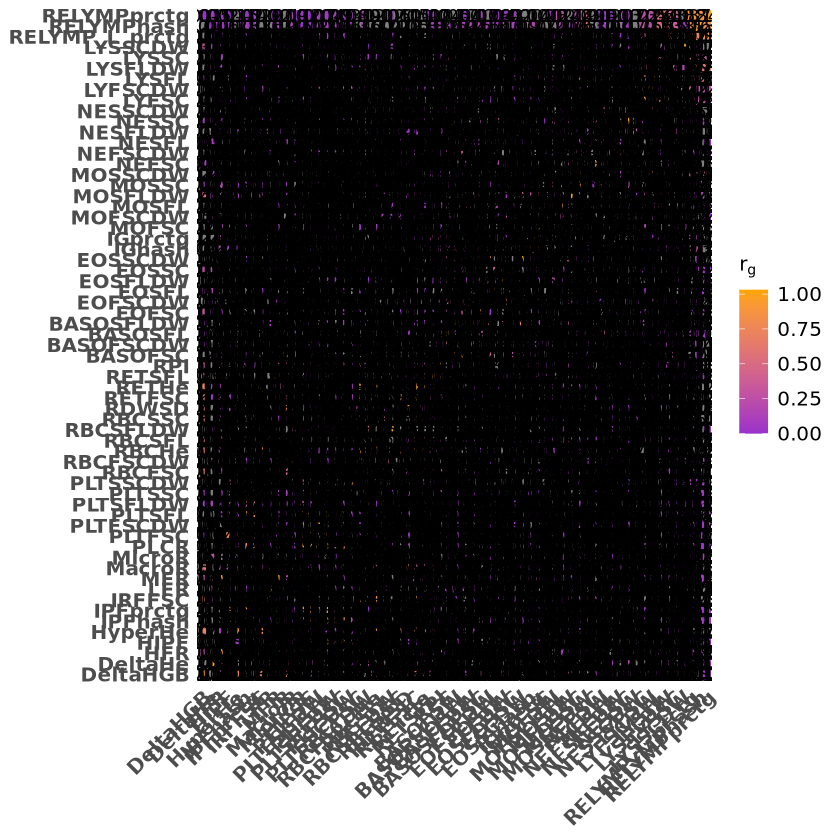

In [120]:
#create the ggplot
correlation_plot <- ggplot(expanded_df_annotated, aes(x = x, y = y, fill = values)) +
scale_fill_gradient(low = "darkorchid", high = "orange", limits = c(0, max(expanded_df$values))) +
theme_minimal() +
geom_tile() +
theme(axis.text = element_text(face = "bold", size = 12), axis.title = element_blank(), legend.text = element_text(size = 12), legend.title = element_text(size = 12), axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(fill = expression(r[g])) +
geom_text(aes(label = values)) +
geom_text(aes(label = paste0("(",se,")"), vjust = 2))

correlation_plot

In [121]:
ggsave("/local1/home/pazweifel/plots/blood/correlations_all.pdf", plot = correlation_plot, width = 40, height = 40, device = "pdf")

In [122]:
expanded_df_annotated %>% group_by(category, x) %>% summarise(mean_corr = mean(values)) %>% arrange(category, desc(mean_corr)) %>% slice_head(n=3) %>% ungroup()

`summarise()` has grouped output by 'category'. You can override using the
`.groups` argument.


category,x,mean_corr
<fct>,<fct>,<dbl>
MEP,RETHe,0.10809524
MEP,RBCFSC,0.10460317
MEP,HyperHe,0.10412698
GMP,BASOSFLDW,0.08380952
GMP,MOSSC,0.08031746
GMP,BASOFSCDW,0.07206349
CLP,RELYMPhash,0.09984127
CLP,LYSFLDW,0.09031746
CLP,LYSSC,0.08031746


No good results, try clustering

In [123]:
library(tibble)
mat <- expanded_df_annotated %>%
  select(x, y, values) %>%
  pivot_wider(names_from = y, values_from = values) %>%
  column_to_rownames("x") %>%
  as.matrix()

hc <- hclust(as.dist(1 - mat), method = "ward.D2")

Warning message:
“package ‘tibble’ was built under R version 4.4.3”


In [124]:
ord <- hc$order
mat <- mat[ord, ord]

In [125]:
pdf("/local1/home/pazweifel/plots/blood/heatmap_all.pdf")
heatmap(mat,
        labRow = rownames(mat),
        labCol = colnames(mat),
        cexRow = 0.6,     # shrink row labels
        cexCol = 0.6) 
dev.off()

agg_record_107763050 
                   2

### S-LDSC with separate annotation at a time

In [126]:
list.files("sldsc_individual_annotation_covstructs/")


[1] "S_LDSC_blood_factors_fsc_ssc_CD14_low_CD16_positive_monocyte.rds"                    
 [2] "S_LDSC_blood_factors_fsc_ssc_CD14_positive_monocyte.rds"                             
 [3] "S_LDSC_blood_factors_fsc_ssc_CD16_negative_CD56_bright_natural_killer_cell_human.rds"
 [4] "S_LDSC_blood_factors_fsc_ssc_CD4_positive_alpha_beta_cytotoxic_T_cell.rds"           
 [5] "S_LDSC_blood_factors_fsc_ssc_CD4_positive_alpha_beta_T_cell.rds"                     
 [6] "S_LDSC_blood_factors_fsc_ssc_CD8_positive_alpha_beta_T_cell.rds"                     
 [7] "S_LDSC_blood_factors_fsc_ssc_central_memory_CD4_positive_alpha_beta_T_cell.rds"      
 [8] "S_LDSC_blood_factors_fsc_ssc_central_memory_CD8_positive_alpha_beta_T_cell.rds"      
 [9] "S_LDSC_blood_factors_fsc_ssc_Control.rds"                                            
[10] "S_LDSC_blood_factors_fsc_ssc_conventional_dendritic_cell.rds"                        
[11] "S_LDSC_blood_factors_fsc_ssc_dendritic_cell.rds"                                     
[12] "S_LDSC_blood_factors_fsc_ssc_double_negative_thymocyte.rds"                          
[13] "S_LDSC_blood_factors_fsc_ssc_effector_memory_CD4_positive_alpha_beta_T_cell.rds"     
[14] "S_LDSC_blood_factors_fsc_ssc_effector_memory_CD8_positive_alpha_beta_T_cell.rds"     
[15] "S_LDSC_blood_factors_fsc_ssc_erythrocyte.rds"                                        
[16] "S_LDSC_blood_factors_fsc_ssc_gamma_delta_T_cell.rds"                                 
[17] "S_LDSC_blood_factors_fsc_ssc_hematopoietic_precursor_cell.rds"                       
[18] "S_LDSC_blood_factors_fsc_ssc_innate_lymphoid_cell.rds"                               
[19] "S_LDSC_blood_factors_fsc_ssc_memory_B_cell.rds"                                      
[20] "S_LDSC_blood_factors_fsc_ssc_mucosal_invariant_T_cell.rds"                           
[21] "S_LDSC_blood_factors_fsc_ssc_naive_B_cell.rds"                                       
[22] "S_LDSC_blood_factors_fsc_ssc_naive_thymus_derived_CD4_positive_alpha_beta_T_cell.rds"
[23] "S_LDSC_blood_factors_fsc_ssc_naive_thymus_derived_CD8_positive_alpha_beta_T_cell.rds"
[24] "S_LDSC_blood_factors_fsc_ssc_natural_killer_cell.rds"                                
[25] "S_LDSC_blood_factors_fsc_ssc_peripheral_blood_mononuclear_cell.rds"                  
[26] "S_LDSC_blood_factors_fsc_ssc_plasmablast.rds"                                        
[27] "S_LDSC_blood_factors_fsc_ssc_plasmacytoid_dendritic_cell.rds"                        
[28] "S_LDSC_blood_factors_fsc_ssc_platelet.rds"                                           
[29] "S_LDSC_blood_factors_fsc_ssc_regulatory_T_cell.rds"                                  
[30] "S_LDSC_blood_factors_fsc_ssc_transitional_stage_B_cell.rds"

In [127]:
model<-'F1 =~NA*RBCSSC+RBCFSC+RETFSC+IRFFSC
F2 =~NA*NEFSC+EOSSC+EOFSC+BASOFSC
F3 =~NA*PLTSSC+PLTFSC
F4 =~NA*EOSSC+EOFSC+BASOFSC+LYSSC+LYFSC
F1~~F2
F1~~F3
F1~~F4
F2~~F3
F2~~F4
F3~~F4
EOFSC ~~ a*EOFSC
a > 0.0001'

params<-c("F1~~F1","F2~~F2","F3~~F3","F4~~F4")

#use unit variance identification
std.lv=TRUE

#estimate enrichment using the enrich function
enrich_gwasbysub<-enrich(s_covstruc=sldsc_covstruct,model=model,params=params,std.lv=std.lv, rm_flank = TRUE)

[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 114 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


In [128]:
library(dplyr)
library(stringr)
library(purrr)

covstruct_dir <- "sldsc_individual_annotation_covstructs"

covstruct_files <- list.files(
  path = covstruct_dir,
  pattern = "\\.rds$",
  full.names = TRUE
)

annotation_names <- str_extract(
  basename(covstruct_files),
  "(?<=ssc_).*(?=\\.rds$)"
)

model <- '
F1 =~ NA*RBCSSC + RBCFSC + RETFSC + IRFFSC
F2 =~ NA*NEFSC + EOSSC + EOFSC + BASOFSC
F3 =~ NA*PLTSSC + PLTFSC
F4 =~ NA*EOSSC + EOFSC + BASOFSC + LYSSC + LYFSC
F1~~F2
F1~~F3
F1~~F4
F2~~F3
F2~~F4
F3~~F4
EOFSC ~~ a*EOFSC
a > 0.0001
'

params <- c("F1~~F1", "F2~~F2", "F3~~F3", "F4~~F4")
std.lv <- TRUE

# turn full annotation path into plain annotation name
clean_annotation <- function(x) {
  x <- as.character(x)
  x <- str_replace(x, "/+$", "")   # remove trailing slash(es)
  x <- ifelse(str_detect(x, "/"), basename(x), x)
  x
}

all_enrichments <- map2_dfr(covstruct_files, annotation_names, function(file_path, annotation_name) {
  
  message("Processing: ", annotation_name)
  
  sldsc_covstruct <- readRDS(file_path)
  
  enrich_out <- enrich(
    s_covstruc = sldsc_covstruct,
    model = model,
    params = params,
    std.lv = std.lv,
    rm_flank = TRUE,
    tau = TRUE
  )
  
  enrich_df <- bind_rows(enrich_out, .id = "Factor") %>%
    mutate(
      Factor = as.integer(Factor),
      Annotation_clean = clean_annotation(Annotation)
    )
  
  out <- enrich_df %>%
    filter(Annotation_clean == annotation_name) %>%
    mutate(Source_annotation = annotation_name)
  
  if (nrow(out) == 0) {
    message("No rows matched for: ", annotation_name)
    message("Available cleaned annotations:")
    print(unique(enrich_df$Annotation_clean))
  }
  
  out
})

write.table(
  all_enrichments,
  file = "combined_factor_annotation_enrichments.tsv",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE
)

Warning message:
“package ‘purrr’ was built under R version 4.4.3”

Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose


Processing: CD14_low_CD16_positive_monocyte



[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 85 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


Processing: CD14_positive_monocyte



[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 85 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


Processing: CD16_negative_CD56_bright_natural_killer_cell_human



...

[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 85 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


Processing: regulatory_T_cell



[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 85 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


Processing: transitional_stage_B_cell



[1] "baseL2 is assumed to be the baseline annotation that includes all SNPs."
[1] "Running model for baseline annotation"
[1] "Confirming fixed model reproduces estimate from freely estimated model for baseline annotation."
[1] "Beginning estimation of enrichment for 85 functional annotations."
[1] "33 annotations were removed from the output because they were either continuous or flanking window annotatoins."


In [129]:
library(dplyr)
library(stringr)

clean_annotation <- function(x) {
  x <- as.character(x)
  x <- str_replace(x, "/+$", "")   # remove trailing slashes
  x <- ifelse(str_detect(x, "/"), basename(x), x)
  x
}

all_enrichments <- all_enrichments %>%
  mutate(Annotation = clean_annotation(Annotation))

In [130]:
lookup <- c("1" = "RBC", "2" = "Granulocytes", "3" = "Platelets", "4" = "Lymphocytes/Granulocytes")

all_enrichments$Factor <- lookup[all_enrichments$Factor]
significance_level <- 0.05/length(unique(all_enrichments$Annotation))


factor_order <- c("RBC", "Granulocytes","Platelets","Lymphocytes/Granulocytes")

In [131]:
all_enrichments <- all_enrichments %>% 
mutate(Bonf = Enrichment_p_value*length(unique(Annotation)), sig = Bonf < 0.05, log10p = -log10(Enrichment_p_value), group = lookup_groups[Annotation], Factor = factor(Factor, levels = factor_order)) %>% 
arrange(Factor, group, Annotation) %>% 
mutate(group = factor(group, levels = unique(group)), Annotation = factor(Annotation, levels = unique(Annotation))) %>%
filter(group != "Control")

In [132]:
group_colors <- c(
  "T" = "#0072B2",                   # blue
  "B" = "#E69F00",                   # orange
  "Precursors/Unspecific" = "#009E73",  # bluish green
  "Dendritic" = "#CC79A7",           # reddish purple
  "NK" = "#56B4E9",                  # sky blue
  "Monocytes" = "#D55E00",           # vermillion
  "RBC/platelet" = "#F0E442"         # yellow
)

all_enrichments$Factor <- recode(all_enrichments$Factor, Granulocytes = "F[Gran]", `Lymphocytes/Granulocytes` = "F[GranLy]", Platelets = "F[Plat]", RBC = "F[RBC]")

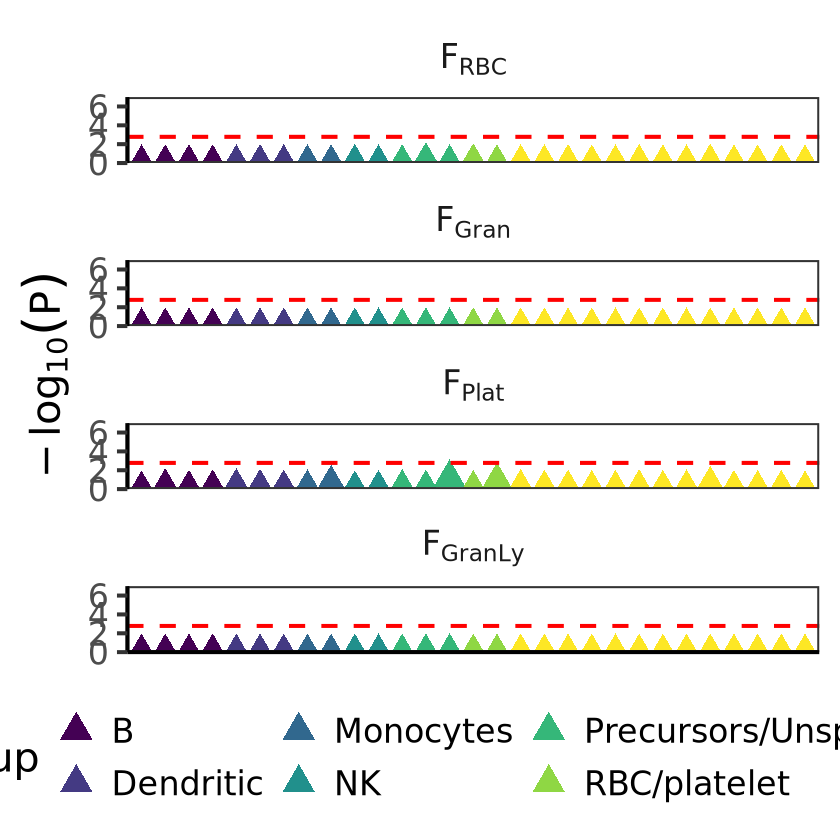

In [133]:
enrich_plot_oneatatime <- ggplot(all_enrichments, aes(x = Annotation, y = log10p)) +
geom_point(aes(color = group), size = 6, shape = 17) +
theme_bw(base_size = 25) +
geom_hline(yintercept = -log10(significance_level), color = "red", linetype = "dashed") +
scale_color_viridis_d(option = "D") +
geom_label_repel(data = filter(all_enrichments, sig == TRUE), aes(label = Annotation)) +
labs(y = expression(-log[10](P)), color = "Group") +
facet_wrap(vars(Factor), nrow = 4, labeller = label_parsed) + 
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank(), legend.position = "bottom") +
scale_y_continuous(limits = c(0, 7), expand = c(0, 0))



enrich_plot_oneatatime

In [134]:
ggsave(filename = "/local1/home/pazweifel/plots/blood/enrichment_4_factors_ldsc_onatatime_nocontrol.pdf", plot = enrich_plot_oneatatime, device = "pdf", width = 20, height = 16)

In [135]:
write_csv(all_enrichments, "/local1/home/pazweifel/plots/blood/stratifiedgsem_oneatatime.csv")

### Combined plots

In [136]:
###figure 2: plots --> enrich_plot, sldsc_plot

In [137]:
library(cowplot)

Warning message:
“ggrepel: 6 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


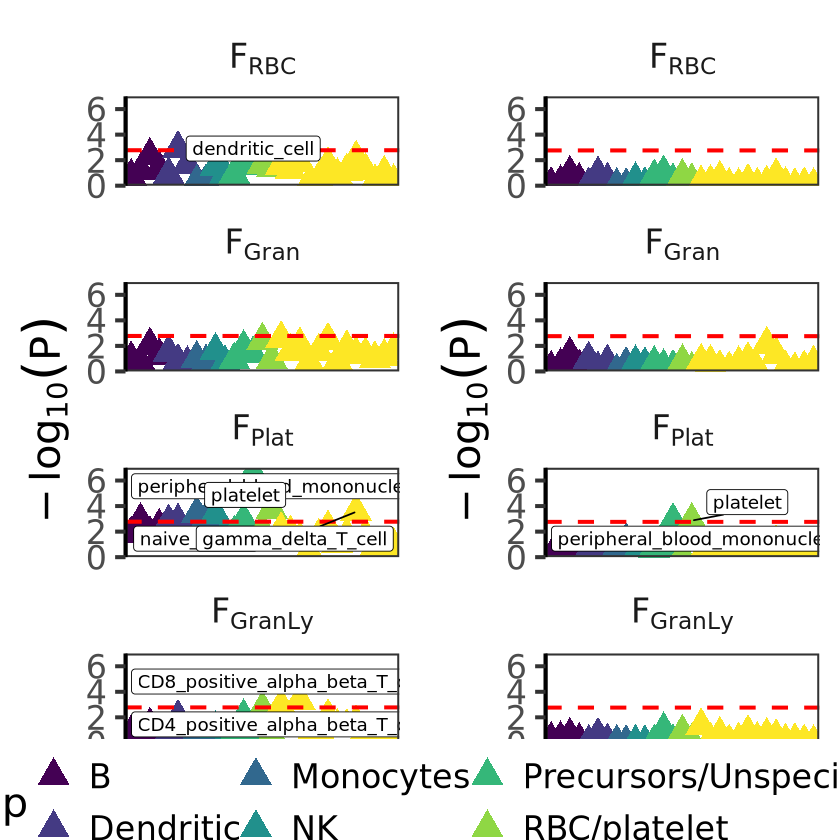

In [138]:
common_legend <- get_legend(enrich_plot)

enrich_plot_wol <- enrich_plot + theme(legend.position = "none")

sldsc_plot_wol <- sldsc_plot + theme(legend.position = "none")

combined_plot_fig2 <- plot_grid(plotlist = list(enrich_plot_wol, sldsc_plot_wol), ncol = 2)
combined_plot_fig2_complete <- plot_grid(
    plotlist = list(combined_plot_fig2, common_legend),
    nrow = 2,
    rel_heights = c(1, 0.1)
    )

combined_plot_fig2_complete

In [139]:
ggsave("/local1/home/pazweifel/plots/blood/figure2.pdf", plot = combined_plot_fig2_complete, device = "pdf", width = 14, height = 14)

In [140]:
### Figure 3: plots --> enrich_plot_tau, enrich_plot_oneatatime

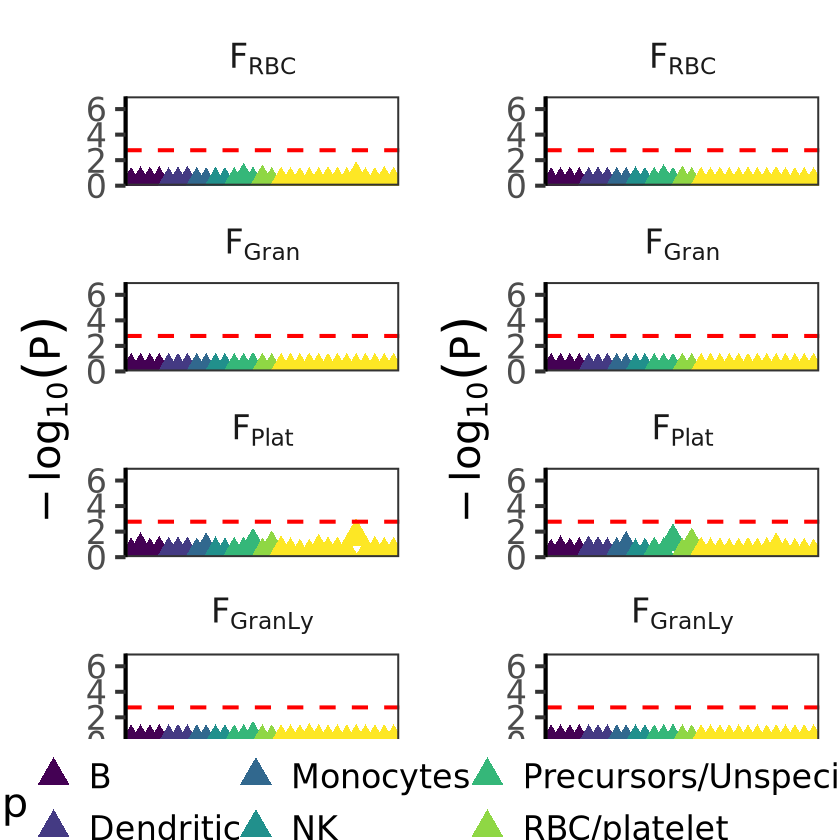

In [141]:
common_legend <- get_legend(enrich_plot_tau)

enrich_plot_tau_wol <- enrich_plot_tau + theme(legend.position = "none")

enrich_plot_oneatatime_wol <- enrich_plot_oneatatime + theme(legend.position = "none")

combined_plot_fig3 <- plot_grid(plotlist = list(enrich_plot_tau_wol, enrich_plot_oneatatime_wol), ncol = 2)
combined_plot_fig3_complete <- plot_grid(
    plotlist = list(combined_plot_fig3, common_legend),
    nrow = 2,
    rel_heights = c(1, 0.1)
    )

combined_plot_fig3_complete

In [142]:
ggsave("/local1/home/pazweifel/plots/blood/figure3.pdf", plot = combined_plot_fig3_complete, device = "pdf", width = 14, height = 14)

ABBRV,Trait,N,source_DOI
<chr>,<chr>,<dbl>,<chr>
PLTSSC,Platelet side scatter,29675,10.1038/s41467-023-40679-y
PLTSFL,Platelet side fluorescence,29678,10.1038/s41467-023-40679-y
PLTFSC,Platelet forward scatter,29662,10.1038/s41467-023-40679-y
PLTSSCDW,Platelet side scatter distribution width,29658,10.1038/s41467-023-40679-y
PLTSFLDW,Platelet side fluorescence distribution width,29552,10.1038/s41467-023-40679-y
PLTFSCDW,Platelet forward scatter distribution width,29618,10.1038/s41467-023-40679-y
HIPF,High fluorescence immature platelet fraction,36829,10.1038/s41467-023-40679-y
IPFhash,Immature platelet count,36618,10.1038/s41467-023-40679-y
IPFprctg,Immature platelet fraction,36615,10.1038/s41467-023-40679-y
